In [1]:
import os
import tarfile
import numpy as np
# import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    "#843c39", # Dark red
    "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses

new_models = [
    "collect.SV-min",
    "collect.SV-min-HFBcut5",
    "collect.UNEDF1-BCScut5-rho16",
    "collect.UNEDF1.HFB-rho16",
    "collect.Fystd",
    "collect.FyDr",
    "collect.FyDrHFB",
    "collect.FyIVP-stab05",
]

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
CR_experimental = pd.read_csv(r'C:/Users/congn/OneDrive/Desktop/An Le Materials/ModelOrthogonalization/data/charge_radii.csv') # I download the radii data separately
CR_experimental.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True) # Rename the column N, Z

In [3]:
bailey_data = pd.read_csv(r'C:/Users/congn/OneDrive/Desktop/An Le Materials/ModelOrthogonalization/data/nuclei_min_energies_2.csv')
bailey_data.rename(columns = {'correctedRMS' : 'Fy_Dr_Bailey'}, inplace= True)
bailey_radii = bailey_data[['N' , 'Z', 'Fy_Dr_Bailey']]
bailey_radii

,N,Z,Fy_Dr_Bailey
0,1,1,17.496220
1,2,1,2.428118
2,3,1,2.895436
3,4,1,2.995515
4,5,1,2.978643
...,...,...,...
7883,196,133,6.771723
7884,198,133,6.785927
7885,196,134,6.763275
7886,197,134,6.774266


In [4]:
Fy_IVP = pd.read_csv(r'C:/Users/congn/OneDrive/Desktop/An Le Materials/ModelOrthogonalization/data/fyivp_nuclei_min_energies.csv')
Fy_IVP.rename(columns = {'correctedRMS' : 'Fy_IVP_Bailey'}, inplace= True)
Fy_IVP = Fy_IVP[['N' , 'Z', 'Fy_IVP_Bailey']]
Fy_IVP

,N,Z,Fy_IVP_Bailey
0,1,1,3.160925
1,2,1,2.278118
2,3,1,2.707379
3,4,1,2.847216
4,5,1,2.947092
...,...,...,...
8732,212,140,6.814001
8733,213,140,6.802608
8734,214,140,6.800661
8735,215,140,6.792758


In [5]:
Sudhanva_Fy = pd.read_csv("C:/Users/congn/OneDrive/Desktop/An Le Materials/ModelOrthogonalization/data/Sudhanva_Fy.txt", sep= "\t")
Sudhanva_Fy = Sudhanva_Fy[['Nmass','Ncharge','rmsc']]
Sudhanva_Fy['Nmass'] = Sudhanva_Fy['Nmass'] - Sudhanva_Fy['Ncharge']
Sudhanva_Fy = Sudhanva_Fy.rename(columns = {'Nmass' : 'N', 'Ncharge' : 'Z', 'rmsc' : 'Fy_Dr_Sudhanva'})
Sudhanva_Fy

,N,Z,Fy_Dr_Sudhanva
0,20,20,3.5212
1,22,20,3.5451
2,24,20,3.5400
3,26,20,3.5168
4,28,20,3.4804
5,30,20,3.5307
6,30,28,3.7327
7,32,28,3.7607
8,34,28,3.8214
9,36,28,3.8672


In [6]:
with tarfile.open('data/radii-systematic.tgz', 'r:gz') as tar:
    tar.extractall(path=r"C:\Users\congn\OneDrive\Desktop\An Le Materials\ModelOrthogonalization\data")

In [7]:
# This extracts the csv of data models into a dataframe in python
FyIVP_stab05 = pd.read_csv(r"data\collect.FyIVP-stab05", sep = r'\s+', header=None)

# #This shifts the name of the column to make it match with their correspondings values
FyIVP_stab05.iloc[0, :-1] = FyIVP_stab05.iloc[0, 1:] 
# Delete the last column as it only contains NaN value
FyIVP_stab05 = FyIVP_stab05.iloc[:, :-1]
# Make the column name to be the first row (the is the Z, N, ...)
FyIVP_stab05.columns = FyIVP_stab05.iloc[0]
#Drop the first row as it is no to us anymore
FyIVP_stab05 = FyIVP_stab05.drop(0)
Data_cols = ['N', 'Z', 'E_B', 'r_C']
for col in Data_cols:
    FyIVP_stab05[col] = [float(num) for num in FyIVP_stab05[col].values]
#This step swaps the values in the 2 columns: 'N' and 'Z'
FyIVP_stab05[['N', 'Z']] =   FyIVP_stab05[['Z', 'N']]
#This steps extract the columns of the dataframe:
FyIVP_stab05_cols = list(FyIVP_stab05.columns)
FyIVP_stab05_cols[0], FyIVP_stab05_cols[1] = FyIVP_stab05_cols[1], FyIVP_stab05_cols[0]
FyIVP_stab05.columns = FyIVP_stab05_cols
FyIVP_stab05

,N,Z,r_C,E_B,"Epair,p",Epair_n,gap_p,gap_n,eferm_p,eferm_n
1,14.0,20.0,3.468429,-247.005,-20.703,-2.696,4.044,1.272,1.401,-19.296
2,16.0,20.0,3.450426,-283.245,-15.095,-1.004,3.319,0.721,-0.793,-16.356
3,18.0,20.0,3.479286,-313.813,-13.809,-2.659,3.099,1.159,-3.064,-14.403
4,20.0,20.0,3.479898,-341.863,-8.663,-0.137,2.334,0.286,-5.397,-12.475
5,22.0,20.0,3.508688,-362.986,-8.596,-6.132,2.295,1.773,-7.283,-9.827
...,...,...,...,...,...,...,...,...,...,...
151,212.0,82.0,6.151760,-1800.770,-13.638-118.638,1.243,3.509,-20.128,1.310,NaN
152,214.0,82.0,6.166172,-1798.860,-13.956-120.629,1.254,3.521,-20.379,1.376,NaN
153,216.0,82.0,6.180233,-1796.790,-14.207-122.199,1.261,3.526,-20.631,1.440,NaN
154,218.0,82.0,6.193951,-1794.590,-14.400-123.434,1.266,3.526,-20.882,1.502,NaN


In [8]:
models_data_sets = {}
for model in new_models[:-1]:
    file_path = rf'data\{model}'
    #This helps you to get rid of the first row
    Data_Values = pd.read_csv(file_path, skiprows=1, sep = r'\s+', header=None)
    # This rearrage your column name so that they match with their corresponding value
    Data_Values.iloc[0, :-1] = Data_Values.iloc[0, 1:] 
    # This helps you to get rid of the last column in which in only contains NaN value
    Data_Values = Data_Values.iloc[:, :-1]
    #This takes all the column to be renamed by the first row that you have
    Data_Values.columns = Data_Values.iloc[0]
    # This drops that row so you will get a full dataframe
    Data_Values = Data_Values.drop(0)
    
    #Only drop rows that has NaN value in charge radii and binding energy 
    Data_Values.dropna(subset = ['r_C', 'E_B'])
    
    #Columns that you are intersted in:
    Data_cols = ['N', 'Z', 'E_B', 'r_C']
    for col in Data_cols:
        Data_Values[col] = [float(num) for num in Data_Values[col].values]
    
    Data_Values[['N', 'Z']] =   Data_Values[['Z', 'N']]
    #This steps extract the columns of the dataframe:
    Data_Values_cols = list(Data_Values.columns)
    #This step rearranges the name of the column so that we can later switch the name of the column
    Data_Values_cols[0], Data_Values_cols[1] = Data_Values_cols[1], Data_Values_cols[0]
    
    Data_Values.columns = Data_Values_cols

    print(Data_Values.isna().any())
    
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : -Data_Values["E_B"], 'ChRad': Data_Values['r_C']}

models_data_sets["collect.FyIVP-stab05"] = {"N" : FyIVP_stab05["N"], "Z" : FyIVP_stab05["Z"], "BE" : -FyIVP_stab05["E_B"], 'ChRad': FyIVP_stab05['r_C']}


# This cell helps you to extract a dictionary that contains all the nuclei with BE and radius predictions of all the models we have
# models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models[0]]['N'].tolist(), models_data_sets[models[0]]['Z'].tolist() ]).T
filtered_NZ

N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [9]:
# Change the name of the new models list so that they do not have the collect. part
new_models = [item.replace('collect.', '') if item.startswith('collect.') else item for item in new_models]
# Renaming the columns of the models_data_sets dictionary
models_data_sets = {
    key.replace('collect.', '') if key.startswith('collect.') else key: value
    for key, value in models_data_sets.copy().items()
}

# This is new names of the dataframe's columns 
models_data_sets.keys()

dict_keys(['SV-min', 'SV-min-HFBcut5', 'UNEDF1-BCScut5-rho16', 'UNEDF1.HFB-rho16', 'Fystd', 'FyDr', 'FyDrHFB', 'FyIVP-stab05', 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1'])

## Necessary Functions

In [10]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)

In [11]:
def LDM_extended(params, x): 
    #x = (n,z)
    #params= parameters (volume, surface, curv, sym, ssym, sym_2, Coulomb)
    
    n=x[0]
    z=x[1]
    A = n + z
    I = (n-z)/(n+z)


    return A*params[0] + params[1] * A ** (2/3) + params[2] * A ** (1/3)  +  params[3] * I ** 2*A + \
                + params[4] * (I ** 2) * A ** (2/3) + params[5] * (I ** 4)*A + params[6]*((z**2)/((A)**(1/3))) 

def isospin_radii_model(A, N, Z, r_a, b ,c):
    return r_a * A** (1/3) * (1 - b * (N - Z)/A + c/A)

def filtered_NZ_extraction(filtered_NZ):
    #We want to create a function that takes only even-even nuclei with N,Z >= 8
    filtered_NZ_new = []
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >=8)) & ((isotope[0]%2 == 0) & (isotope[1]%2 == 0)): # Sort the even-even isotope with proton and neutron number 8 or above
            filtered_NZ_new.append(isotope)
    filtered_NZ_new  = np.array(filtered_NZ_new)
    return filtered_NZ_new

def unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ):
    #We want to create a function that extracts nuclei that exist in every models
    for model in models_selected:
        filtered_NZ_new = []
        for isotope in filtered_NZ:
            if ( (isotope[0] == models_data_sets[model]['N']) & (isotope[1] == models_data_sets[model]['Z']) ).any(): # Choose nuclei that are contained in each model
                filtered_NZ_new.append(isotope)
        filtered_NZ = np.array(filtered_NZ_new) #update our new list of isotope and repeat this for every model
    filtered_NZ_df = pd.DataFrame({'N' : filtered_NZ.T[0], 'Z' : filtered_NZ.T[1]})
    return filtered_NZ_new, filtered_NZ_df

def selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, property):
    #We want to create dataframe that contains all the model predictions of a property of interest
    selected_models_data_sets = pd.DataFrame(filtered_NZ_df.copy()) #Initiate the dataframe by the proton and neutron number
    for model in models_selected:
        # Convert the model's dataset to a dataframe (if not already)
        model_df = pd.DataFrame(models_data_sets[model])

        # Merge with selected_models_data_sets to keep only matching isotopes
        merged_df = pd.merge(selected_models_data_sets, model_df, on=['N', 'Z'], how='inner')

        # Update selected_models_data_sets to include only the common isotopes
        selected_models_data_sets = merged_df[['N', 'Z'] + [col for col in selected_models_data_sets.columns if col not in ['N', 'Z']]]

        # Add the model's predictions for the property
        selected_models_data_sets[model] = merged_df[property]

    return selected_models_data_sets

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    #Technically rearrange the columns of the selected_models_data_sets and separate into intrapolation and extrapolation part
    models_output = selected_models_data_sets.copy()
    models_output['A'] = models_output['N'] + models_output['Z'] # Put the mass number in our dataframe
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2] # Rearranging columns 
    models_output = models_output[cols]

    models_output_train = models_output.iloc[train_coordinates] # Training regions
    models_output_validation = models_output.iloc[validation_coordinates] # Validation regions
    models_output_test = models_output.iloc[test_coordinates] # Test regions
    return [models_output, models_output_train, models_output_validation, models_output_test]


def clip_sort(df, N_min, N_max, Z_min, Z_max):
        mask_N = df['N'].between(N_min, N_max)
        out_N = df.loc[mask_N].copy()
        
        mask_Z = out_N['Z'].between(Z_min, Z_max)
        out_Z = out_N.loc[mask_Z].copy()

        return out_Z

def filtered_models_output_extraction(models_output, train_idx, val_idx, test_idx, \
                                      stable_coordinates_df, Z_range, N_range = None):
    """
    Extract [all, train, val, test] slices filtered by Z and N ranges, then sorted.

    Parameters
    ----------
    models_output : pd.DataFrame
        Must contain columns 'Z', 'N', each model column, and 'truth'.
    train_coordinates / validation_coordinates / test_coordinates : sequence[int]
        Positional indices for .iloc to define splits.
    Z_range : (int, int) or None
        Inclusive range of proton numbers to keep. None => no Z filter.
        Use (Z, Z) to get a single element.
    N_range : (int, int)
        Inclusive neutron-number range to keep.

    Returns
    -------
    list[pd.DataFrame] : [all_df, train_df, val_df, test_df]
    """

    if Z_range == None:
        raise ValueError('Must specify the range of Z')
    
    if N_range is None:
        N_range = (0, 300)

    Z_min, Z_max = Z_range[0], Z_range[1]
    N_min, N_max = N_range[0], N_range[1]

    models_output_stable = pd.merge(models_output, stable_coordinates_df, on = ['N', 'Z'], how = 'inner')


    all_df  = clip_sort(models_output, N_min, N_max, Z_min, Z_max)
    train_df = clip_sort(models_output.iloc[train_idx], N_min, N_max, Z_min, Z_max)
    val_df   = clip_sort(models_output.iloc[val_idx], N_min, N_max, Z_min, Z_max)
    test_df  = clip_sort(models_output.iloc[test_idx], N_min, N_max, Z_min, Z_max)
    stable_df = clip_sort(models_output_stable, N_min, N_max, Z_min, Z_max)

    return [all_df, train_df, val_df, test_df, stable_df]


def filtered_predictions_all_elements(models_output, train_idx, val_idx, test_idx, \
                                            stable_coordinates_df, Zs=None):
    """
    Lightweight orchestrator:
    - Picks the Zs to process (defaults to all in models_output).
    - For each Z, calls your two extractors (which already handle N-range & sorting).
    - Returns a dict: Z -> {'all','train','val','test','stable'} DataFrames.
    """
    if Zs is None:
        Zs = sorted(models_output['Z'].unique())

    predictions_dict = {}

    for Z in Zs:
        [all_df, train_df, val_df, test_df, stable_df]= filtered_models_output_extraction(
            models_output,
            train_idx,
            val_idx,
            test_idx,
            stable_coordinates_df,
            Z_range = (Z,Z),
            N_range = None
        )

        predictions_dict[Z] = {
            'all': all_df,
            'train': train_df,
            'val': val_df,
            'test': test_df,
            'stable': stable_df
        }
    return predictions_dict



def filtered_models_output_stable_extraction(Selected_element, models_output, stable_coordinates):
    # Extract models output dataframe for stable isotope for a specific element
    Z_range = (Selected_element, Selected_element) # Choose element we want to analyze
    N_range = (0,300)
    stable_isotopes = []
    for isotope in stable_coordinates:
        if isotope[1] == Selected_element: #Choose isotope that has the same proton number
            stable_isotopes.append(isotope)
    stable_isotopes = np.array(stable_isotopes)
    
    filtered_models_output_stable = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1])\
                                                 & (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1]) & models_output['N'].isin(stable_isotopes.T[0])]
    return filtered_models_output_stable

def filtered_models_output_dict_extraction(Selected_elements, key_name, models_output, train_coordinates, validation_coordinates, test_coordinates, stable_coordinates):
    # This functions helps me to create the filtered models output for different isotopes at the same time and store them in a dictionary
    filtered_models_output_dict = {} # Initiate dictionary
    for j in Selected_elements:
        key = f"{key_name}" + f"{int(j)}" # name is the key-value pair in the dictionary
        # The line below store the list of filtered models output for a specific element in the dictionary
        filtered_models_output_dict[key] = filtered_models_output_extraction(int(j), models_output, train_coordinates, validation_coordinates, test_coordinates)
        # The line below add to the list we have above the stable isotopes into our list
        filtered_models_output_dict[key].append(filtered_models_output_stable_extraction(int(j), models_output, stable_coordinates))
    filtered_models_output_dict.keys() # This is just to check if I had the right name for the list
    return filtered_models_output_dict

def models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output):
    # This fucntions returns the dataframe of 
    models_PC = {}
    models_PC['N'] = models_output['N']
    models_PC['Z'] = models_output['Z']
    models_PC['A'] = models_output['N'] + models_output['Z']
    models_PC['PC_0'] = predictions_mean

    for i in range(len(Vt_hat)):
        models_PC['PC_' + str(i+1)] = Vt_hat[i].dot(model_predictions.T)
    model_PC = pd.DataFrame(models_PC)
    return model_PC

# Right now there are some more functions that we need for the statistical interference but we did not write it here yet
def USVt_hat_extraction(U,S,Vt, components_kept):
    U_hat = np.array([U.T[i] for i in range(components_kept)]).T
    S_hat = S[:components_kept]
    Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
    return U_hat, S_hat, Vt_hat

def super_params(X,y):
    X_T_X = X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)
    super_param = X_T_X_inv.dot(X.T).dot(y) 
    return super_param

def weights_params_translation(super_params, Vt_hat):
    model_weights = np.dot(super_params, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)
    return model_weights

def residuals_calculator(model_weights, model_predictions_list, models_output_list):
    #Note that we for every models output list we put all nuclei first, and then train, validation, test region
    supermodel_full = model_weights.dot(model_predictions_list[0].T)
    supermodel_train = model_weights.dot(model_predictions_list[1].T)
    supermodel_validation = model_weights.dot(model_predictions_list[2].T)
    supermodel_test = model_weights.dot(model_predictions_list[3].T)

    supermodel_residuals_full = supermodel_full-models_output_list[0]['truth'].tolist()
    supermodel_residuals_train=supermodel_train-models_output_list[1]['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_list[2]['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_list[3]['truth'].tolist()

    return supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test

def supermodel_residuals_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    U_hat, S_hat, Vt_hat = USVt_hat_extraction(U,S,Vt, components_kept) # This gives you the approximation matrix
    # Note that we for any list that we create, we will put full dataset first, and then train, validation, test respectively
    # models_PC_train = models_PC_output(Vt_hat, model_predictions_list[1], predictions_mean) # This gives you the matrix of the PCs
    
    # key_list_PCs=list(models_PC_train.keys()) # columns' names of the PCs matrix

    models_PC_train = models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output)
    X = models_PC_train.values[:,4:]# This is the matrix of the PCs
    # print(X.shape)
    y = models_output['truth'] - predictions_mean
    beta = super_params(X,y) #Calculate the best OLS beta
    model_weights = weights_params_translation(beta, Vt_hat) #Translate from the PCs' params to models' weights
    print(model_weights)

    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = residuals_calculator(model_weights,\
                                                                                                            model_predictions_list, models_output_list)

    return [supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test]

def PC_RMSE_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    # model_predictions and predictions_mean are variables that related to PCA decomposition, and models_output part are related to
    # the part where we want to calculate RMSE
    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = supermodel_residuals_calculator(\
                                                            components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt)
    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )
    print(sigma_train)

    return [sigma_full,sigma_train,sigma_validation,sigma_test]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):

        yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]


def rndm_m_random_calculator(filtered_model_predictions, samples, Vt_hat):
    """
    Generates posterior predictive samples and credible intervals.

    Args:
        filtered_model_predictions (numpy.ndarray): Model predictions.
        samples (numpy.ndarray): Gibbs samples `[beta, sigma]`.
        Vt_hat (numpy.ndarray): Normalized right singular vectors.

    Returns:
        tuple[numpy.ndarray, list[numpy.ndarray]]:
            - `rndm_m` (numpy.ndarray): Posterior predictive samples.
            - `[lower, median, upper]` (list[numpy.ndarray]): Credible interval arrays.
    """
    np.random.seed(142858)
    rng = np.random.default_rng()

    theta_rand_selected = rng.choice(samples, 50000, replace=False)

    # Extract betas and noise std deviations
    betas = theta_rand_selected[:, :-1]  # shape: (10000, num_models - 1)
    noise_stds = theta_rand_selected[:, -1]  # shape: (10000,)

    # Compute model weights: shape (10000, num_models)
    default_weights = np.full(Vt_hat.shape[1], 1 / Vt_hat.shape[1])
    model_weights_random = (
        betas @ Vt_hat + default_weights
    )  # broadcasting default_weights

    # Generate noiseless predictions: shape (10000, num_data_points)
    yvals_rand_radius = (
        model_weights_random @ filtered_model_predictions.T
    )  # dot product

    # Add Gaussian noise with std = noise_stds (assume diagonal covariance)
    # We'll use broadcasting: noise_stds[:, None] * standard normal noise
    noise = rng.standard_normal(yvals_rand_radius.shape) * noise_stds[:, None]
    rndm = yvals_rand_radius + noise

    # Compute credible intervals
    lower_radius = np.percentile(rndm, 2.5, axis=0)
    median_radius = np.percentile(rndm, 50, axis=0)
    upper_radius = np.percentile(rndm, 97.5, axis=0)

    return rndm, [lower_radius, median_radius, upper_radius]


def coverage(percentiles, rndm_m, models_output, truth_column):
    """
    Calculates coverage percentages for credible intervals.

    Args:
        percentiles (list[int]): Percentiles to evaluate (e.g., `[5, 10, ..., 95]`).
        rndm_m (numpy.ndarray): Posterior samples of predictions.
        models_output (pandas.DataFrame): DataFrame containing true values.
        truth_column (str): Name of column with true values.

    Returns:
        list[float]: Coverage percentages for each percentile.
    """
    #  How often the model’s credible intervals actually contain the true value
    data_total = len(rndm_m.T)  # Number of data points
    M_evals = len(rndm_m)  # Number of samples
    data_true = models_output[truth_column].tolist()

    coverage_results = []

    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m.T[i])
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
        coverage_results.append(count_covered / data_total * 100)

    return coverage_results

In [12]:
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
df.loc[df['A'].between(2,2)]

,A,B
1,2,5


In [13]:
def plot_model_predictions(filtered_models_output_list, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    # plt.rcParams['text.usetex'] = False
    # plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], filtered_models_output[model],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    plt.legend(fontsize=15,markerscale=1,ncol=2  )
    # plt.savefig(f'{savefig}')
    # plt.show()

def plot_filtered_naive_supermodel(filtered_naive_supermodel_list, filtered_models_output_list, filtered_models_output_stable, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_naive_supermodel_list[0]["N"], filtered_naive_supermodel_list[0]['naive supermodel'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Naive Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

def plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict):
    # Selected_element_list are the name of the elements, Selected_element is the number of proton that element has.
    i = Selected_elements_list.index(element_name)# This gives you the index of the element you want to graph
    dict_keys = list(filtered_models_output_dict.keys()) # This gives you all the keys in the dictionary that we input

    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose

    # color_local= "khaki"

    # This gives you training experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][1]["N"], y = filtered_models_output_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][2]["N"], y = filtered_models_output_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][3]["N"], y = filtered_models_output_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][4]["N"], y = filtered_models_output_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)

def plot_filtered_something_else_dict(Selected_elements_list, element_name, Selected_element, filtered_models_output_dict, filtered_models_something_else_dict, what_you_want_to_graph):
    # plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict) # This plots all the experimental data
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    index = Selected_elements_list.index(element_name) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(filtered_models_something_else_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = filtered_models_something_else_dict[dict_keys[index]][0][what_you_want_to_graph] #This is the dataframe that we want to graph from
    for i in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[i]
        plt.plot(filtered_models_something_else_dict[dict_keys[index]][0]['N'], filtered_models_something_else[column], color= colors[i], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Selected_element}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()
# Let'steal this from Pablo like we always do

def plot_heatmap(xvals, yvals, zvals, quantity_of_interest, model):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 
    
    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_heatmap_3D(xvals, yvals, zvals, title, elev=30, azim=-60):
    # Create figure and 3D axes
    fig, ax_3d = plt.subplots(figsize=(4, 3), dpi=200, subplot_kw={'projection': '3d'})
    
    # Normalize z values
    # z_normalized = (zvals - zvals.min()) / (zvals.max() - zvals.min())
    z_normalized = zvals # This is when we want to see the actual components of the PCs
    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y directions
    dz = z_normalized  # Height of the bars (z values)

    # Create 3D bar plot
    ax_3d.bar3d(xvals, yvals, np.zeros_like(z_normalized), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax_3d.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    # Set view angle
    ax_3d.view_init(elev=elev, azim=azim) 
    
    ax_3d.tick_params(axis='both', labelsize=8)  # Smaller font size for major ticks
    ax_3d.tick_params(axis='z', labelsize=8)
    
    # Set labels and title
    ax_3d.set_xlabel('Neutrons', fontsize = 5)
    ax_3d.set_ylabel('Protons', fontsize = 5)
    ax_3d.set_zlabel('Scaled Z', fontsize = 5)
    ax_3d.set_title(title)

    # Create a colorbar based on the plasma colormap and the normalization
    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)
    
    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax_3d, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    # Show plot
    # plt.show()

def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, filtered_models_output_stable, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], median, color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], lower, color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], upper, color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], lower, upper, color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

def plot_filtered_supermodel_simplex(supermodel_predictions_range, filtered_models_output_list, filtered_models_output_stable, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], median, color="purple", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], lower, color="purple",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], upper, color="purple",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], lower, upper, color="purple",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:212: SyntaxWarning: invalid escape sequence '\d'
<>:233: SyntaxWarning: invalid escape sequence '\m'
<>:235: SyntaxWarning: invalid escape sequence '\m'
<>:237: SyntaxWarning: invalid escape sequence '\m'
<>:272: SyntaxWarning: invalid escape sequence '\d'
<>:293: SyntaxWarning: invalid escape sequence '\m'
<>:295: SyntaxWarning: invalid escape sequence '\m'
<>:297: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarnin

In [15]:
def Plotter2D_single(xvals, yvals, zvals, validation_set, quantity_of_interest, model):
    # xvals,yvals,zvals = data
    #A plotter to see principal components in 2D
    plt.rc("xtick", labelsize=25)
    plt.rc("ytick", labelsize=25)
    
    fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=25)
    ax.scatter(validation_set.T[0], validation_set.T[1], color = 'black', alpha = 1, marker = 'o', s = 35)
    cbar.ax.tick_params(labelsize=20) 
    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    ax.grid(True)
    # ax.axis('equal')
    plt.title(f'{model}', fontsize = 25)
    # plt.show()

def Plotter3D_single(xvals, yvals, zvals, title, elev=30, azim=-60):
    # xvals,yvals,zvals = data
    #A plotter to see principal components in 3D
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)

    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = zvals

    # Create figure for 3D plot
    fig = plt.figure(figsize=(8, 6), dpi=200)
    ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Z value')
    ax.set_title(title)

    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)

    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=20)
    cbar.ax.tick_params(labelsize=20)
    
    # plt.show()



def Plotter2D(ax, xvals, yvals, zvals, validation_set, quantity_of_interest, model):
    #A plotter to see principal components in 2D, part of the big plotter


    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    ax.scatter(validation_set.T[0], validation_set.T[1], color = 'black', alpha = 1, marker = 'o', s = 35)
    cbar.set_label(f'{quantity_of_interest}', fontsize=25) 
    cbar.ax.tick_params(labelsize=20) 




    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    plt.title(f'{model}', fontsize = 25)
    ax.grid(True)
    ax.axis('equal')

    # plt.show()

def Plotter3D(ax,xvals,yvals,zvals,elev=30,azim=-60):
    #A plotter to see principal components in 3D, part of the big plotter
    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = zvals

    # Create figure for 3D plot
    # fig = plt.figure(figsize=(8, 6), dpi=200)
    # ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Scaled Z')


    # plt.show()    



def PlotMultiple(xvals, yvals, zvals, validation_set, quantity_of_interest, model, angles_sheet=None):
    # Determine the number of rows needed for the plots
    # n_rows = len(data_sets)
    # Each data_sets element should look like [x,y,z]

    # Create a figure with subplots
    fig = plt.figure(figsize=(20, 8), dpi=200)


    # 2D plot
    ax_2d = fig.add_subplot(1, 2, 1)
    Plotter2D(ax_2d, xvals, yvals, zvals, validation_set, quantity_of_interest, model)

    # 3D plot
    ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
    if angles_sheet == None:
        Plotter3D(ax_3d, xvals, yvals, zvals)
    else:
        Plotter3D(ax_3d, xvals, yvals, zvals,elev=angles_sheet[0],azim=angles_sheet[1])

    plt.tight_layout()
    # plt.show()


In [16]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above

In [17]:
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models, filtered_NZ)


In [18]:
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models + new_models, filtered_NZ_df, 'ChRad')


# This is for the radius data
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, bailey_radii[['N', 'Z',  'Fy_Dr_Bailey']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, Sudhanva_Fy[['N', 'Z',  'Fy_Dr_Sudhanva']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, Fy_IVP[['N', 'Z',  'Fy_IVP_Bailey']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, CR_experimental[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

C:\Users\congn\AppData\Local\Temp\ipykernel_28048\1811004923.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\congn\AppData\Local\Temp\ipykernel_28048\1811004923.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\congn\AppData\Local\Temp\ipykernel_28048\1811004923.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [19]:
selected_models_data_sets_radius

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,...,SV-min-HFBcut5,UNEDF1-BCScut5-rho16,UNEDF1.HFB-rho16,Fystd,FyDr,FyDrHFB,FyIVP-stab05,Fy_Dr_Bailey,Fy_Dr_Sudhanva,Fy_IVP_Bailey
0,20,20,3.4776,3.465,3.425,3.457,3.470,3.508447,3.530085,3.508657,...,3.489933,3.499238,3.494464,3.481121,3.456278,3.480780,3.479898,3.489192,3.5212,3.482462
1,22,20,3.5081,3.469,3.435,3.463,3.468,3.513530,3.536751,3.515920,...,3.487507,3.498409,3.495466,3.482421,3.515043,3.514082,3.508688,3.516966,3.5451,3.512238
2,24,20,3.5179,3.474,3.447,3.472,3.469,3.517619,3.543701,3.522998,...,3.489881,3.500371,3.499346,3.487125,3.500920,3.522877,3.517010,3.528269,3.5400,3.519892
3,26,20,3.4953,3.479,3.459,3.481,3.472,3.523560,3.552996,3.531629,...,3.494579,3.504425,3.504437,3.493322,3.502032,3.510142,3.493966,3.513955,3.5168,3.498698
4,28,20,3.4771,3.481,3.468,3.490,3.474,3.533390,3.564701,3.543605,...,3.500632,3.512822,3.512195,3.500746,3.451782,3.481027,3.480710,3.480137,3.4804,3.479839
5,30,20,3.5168,3.512,3.496,3.511,3.498,3.547856,3.578512,3.559659,...,3.517091,3.529348,3.528388,3.519997,3.519194,3.524258,3.520143,3.525194,3.5307,3.521011
6,30,28,3.7757,3.758,3.817,3.777,3.740,3.796573,3.834224,3.813072,...,3.779552,3.784227,3.783821,3.770102,3.741814,3.731653,3.737411,3.731324,3.7327,3.743048
7,32,28,3.8118,3.804,3.838,3.827,3.768,3.812996,3.848746,3.829694,...,3.793972,3.806146,3.805062,3.790042,3.773738,3.755224,3.756722,3.757160,3.7607,3.757962
8,34,28,3.8399,3.833,3.845,3.826,3.794,3.835217,3.868574,3.861478,...,3.823363,3.833020,3.833748,3.819184,3.818998,3.810162,3.817157,3.812843,3.8214,3.835223
9,36,28,3.8572,3.838,3.829,3.846,3.818,3.860132,3.891267,3.880534,...,3.849051,3.857569,3.858994,3.848699,3.855236,3.855190,3.860228,3.857294,3.8672,3.867670


In [26]:
selected_models_data_sets_radius['FyDr_PG_Bailey'] = selected_models_data_sets_radius['FyDr'].values - selected_models_data_sets_radius['Fy_Dr_Bailey'].values
selected_models_data_sets_radius['FyDr_PG_Sudhanva'] = selected_models_data_sets_radius['FyDr'].values - selected_models_data_sets_radius['Fy_Dr_Sudhanva'].values
selected_models_data_sets_radius['FyIVP_PG_Bailey'] = selected_models_data_sets_radius['FyIVP-stab05'].values - selected_models_data_sets_radius['Fy_IVP_Bailey'].values
selected_models_data_sets_radius['FyDr_Bailey_Sudhanva'] = selected_models_data_sets_radius['Fy_Dr_Bailey'].values - selected_models_data_sets_radius['Fy_Dr_Sudhanva'].values


selected_models_data_sets_radius = selected_models_data_sets_radius[['N', 'Z', 'FyDr_PG_Bailey', 'FyDr_PG_Sudhanva','FyIVP_PG_Bailey', 'FyDr_Bailey_Sudhanva']]
selected_models_data_sets_radius

,N,Z,FyDr_PG_Bailey,FyDr_PG_Sudhanva,FyIVP_PG_Bailey,FyDr_Bailey_Sudhanva
0,20,20,-0.032914,-0.064922,-0.002564,-0.032008
1,22,20,-0.001923,-0.030057,-0.003550,-0.028134
2,24,20,-0.027349,-0.039080,-0.002882,-0.011731
3,26,20,-0.011923,-0.014768,-0.004732,-0.002845
4,28,20,-0.028355,-0.028618,0.000871,-0.000263
5,30,20,-0.006000,-0.011506,-0.000868,-0.005506
6,30,28,0.010490,0.009114,-0.005637,-0.001376
7,32,28,0.016578,0.013038,-0.001240,-0.003540
8,34,28,0.006155,-0.002402,-0.018066,-0.008557
9,36,28,-0.002058,-0.011964,-0.007442,-0.009906


### From the difference between experience between Bailey, Sudhanva and PG data, we decided that we will perform BMM on Bailey's IVP difference since it has the least deviation from PG's. Additionally, it provides calculation of charge radii for the whole chart nuclei.

In [20]:
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models, filtered_NZ_df, 'ChRad')


# This is for the radius data
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, Fy_IVP[['N', 'Z',  'Fy_IVP_Bailey']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, bailey_radii[['N', 'Z',  'Fy_Dr_Bailey']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, CR_experimental[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

selected_models_data_sets_radius

C:\Users\congn\AppData\Local\Temp\ipykernel_28048\1811004923.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\congn\AppData\Local\Temp\ipykernel_28048\1811004923.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\congn\AppData\Local\Temp\ipykernel_28048\1811004923.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,Fy_IVP_Bailey,Fy_Dr_Bailey
0,8,8,2.6991,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816,2.774552,2.753890
1,10,8,2.7726,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329,2.835790,2.828447
2,8,10,2.9714,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445,2.951307,2.993670
3,10,10,3.0055,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315,3.000327,3.019625
4,12,10,2.9525,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485,3.001396,3.028387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,5.8948,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415,5.903815,5.915108
341,146,96,5.8285,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126,5.902992,5.911279
342,148,96,5.8429,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104,5.915440,5.924613
343,150,96,5.8562,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470,5.927410,5.938320


In [21]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()


# np.savetxt('data/selected_NZ_radius.txt', filtered_NZ_df, fmt="%.6f", delimiter="\t", header= 'N\tZ', comments='')

In [22]:
pd.merge(filtered_NZ_df, filtered_NZ_df_radius, on = ['N', 'Z'], how = 'inner')

,N,Z
0,8,8
1,10,8
2,8,10
3,10,10
4,12,10
...,...,...
340,150,94
341,146,96
342,148,96
343,150,96


In [23]:
stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

In [24]:
stable_coordinates

array([[  8.,   8.],
       [ 10.,   8.],
       [ 10.,  10.],
       [ 12.,  10.],
       [ 12.,  12.],
       [ 14.,  12.],
       [ 14.,  14.],
       [ 16.,  14.],
       [ 16.,  16.],
       [ 18.,  16.],
       [ 20.,  16.],
       [ 18.,  18.],
       [ 20.,  18.],
       [ 22.,  18.],
       [ 20.,  20.],
       [ 22.,  20.],
       [ 24.,  20.],
       [ 26.,  20.],
       [ 28.,  20.],
       [ 24.,  22.],
       [ 26.,  22.],
       [ 28.,  22.],
       [ 26.,  24.],
       [ 28.,  24.],
       [ 30.,  24.],
       [ 28.,  26.],
       [ 30.,  26.],
       [ 32.,  26.],
       [ 30.,  28.],
       [ 32.,  28.],
       [ 34.,  28.],
       [ 36.,  28.],
       [ 34.,  30.],
       [ 36.,  30.],
       [ 38.,  30.],
       [ 40.,  30.],
       [ 38.,  32.],
       [ 40.,  32.],
       [ 42.,  32.],
       [ 44.,  32.],
       [ 40.,  34.],
       [ 42.,  34.],
       [ 44.,  34.],
       [ 46.,  34.],
       [ 48.,  34.],
       [ 42.,  36.],
       [ 44.,  36.],
       [ 46.,

### We now need to separate these nuclei to interpolation and extrapolation regions

In [25]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

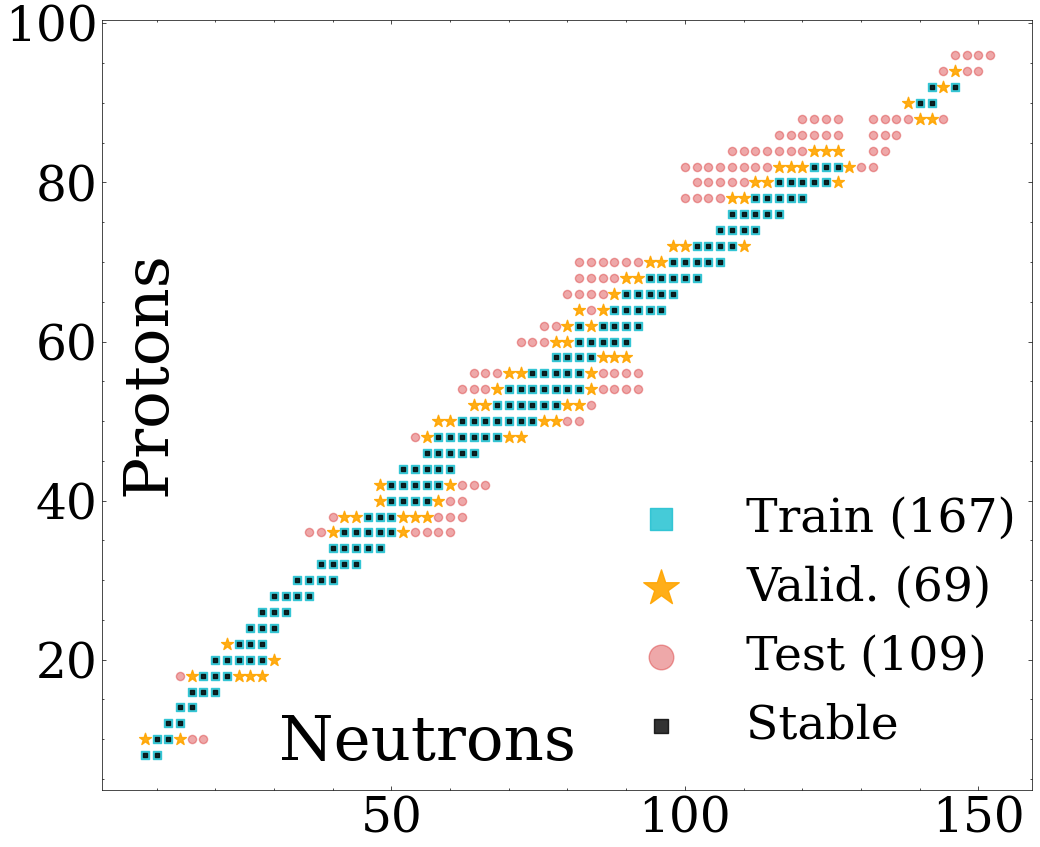

In [27]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(12,10), dpi=100)

plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

ax.scatter(x = training_set_radius.T[0], y = training_set_radius.T[1], label = "Train ("+ str(len(training_set_radius))+")", alpha = alpha_train,color=color_train,s=size_train,marker=marker_train)

ax.scatter(x = validation_set_radius.T[0], y = validation_set_radius.T[1], label = "Valid. (" + str(len(validation_set_radius))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)

ax.scatter(x = test_set_radius.T[0], y = test_set_radius.T[1], label = "Test (" + str(len(test_set_radius))+")", alpha = alpha_test,color=color_test,s=size_test,marker=marker_test)

ax.scatter(x = stable_coordinates_radius.T[0], y = stable_coordinates_radius.T[1], label = "Stable", alpha = 0.8,color='black',s=11,marker="s")





# ax.scatter(x = np.array(AME2020New).T[0], y = np.array(AME2020New).T[1], label = "Valid. (" + str(len(validation_set))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)


plt.xlabel('')

plt.annotate('Neutrons', xy=(0.35, 0.1), xycoords='axes fraction',
             ha='center', va='top', fontsize=45) 
plt.ylabel('')

plt.annotate('Protons', xy=(0.05,0.7), xycoords='axes fraction',
             ha='center', va='top', fontsize=45,rotation =90) 


# plt.ylabel("Protons",fontsize=45)
plt.legend(fontsize=34,markerscale=3 ,loc =(0.53,0.03))
# plt.savefig('Plots/Radii Data with Bailey/Nuclei chart/whole_nuclei_chart.png')

plt.show()

In [28]:
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [29]:
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [30]:
trial = pd.merge(models_output_radius, stable_coordinates_radius_df, on = ['N', 'Z'], how = 'inner')
trial

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,Fy_IVP_Bailey,Fy_Dr_Bailey,truth
0,8,8,16,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816,2.774552,2.753890,2.6991
1,10,8,18,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329,2.835790,2.828447,2.7726
2,10,10,20,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315,3.000327,3.019625,3.0055
3,12,10,22,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485,3.001396,3.028387,2.9525
4,12,12,24,3.079,3.035,3.112,3.053,3.095257,3.115114,3.117943,3.117073,3.056209,3.104676,3.119922,3.155711,3.0570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,126,82,208,5.518,5.509,5.513,5.509,5.510275,5.527429,5.517656,5.504514,5.510208,5.519245,5.488102,5.487335,5.5012
163,140,90,230,5.801,5.756,5.796,5.801,5.779119,5.785321,5.787366,5.770657,5.772393,5.789926,5.769433,5.789928,5.7670
164,142,90,232,5.822,5.768,5.817,5.823,5.792752,5.799963,5.802321,5.786596,5.788649,5.806728,5.787037,5.806752,5.7848
165,142,92,234,5.852,5.794,5.847,5.851,5.833980,5.842323,5.841207,5.823755,5.825402,5.842084,5.816275,5.822011,5.8291


In [31]:
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

filtered_models_output_radius_list_20 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, validation_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (20,20))

filtered_models_output_radius_list_28 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, validation_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (28,28))

filtered_models_output_radius_list_50 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, validation_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (50,50))

filtered_models_output_radius_list_82 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, validation_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (82,82))


models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1', 'Fy_Dr_Bailey','Fy_IVP_Bailey']#Here I am copying all the models with Charge Raidus and Masses

key_list = models_selected

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

In [32]:
centering_data = True

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]


if centering_data:
    model_predictions_radius_validation_processed = model_predictions_radius_validation - predictions_mean_radius_validation[:,None]
    model_predictions_radius_test_processed = model_predictions_radius_test - predictions_mean_radius_test[:,None]
    model_predictions_radius_processed = model_predictions_radius - predictions_mean_radius[:,None]

[5.23799807e-01 3.87825241e-01 2.64030661e-01 1.79275707e-01
 1.38861571e-01 1.10063685e-01 8.73111156e-02 7.69500277e-02
 6.65397257e-02 6.13013430e-02 4.41901957e-02 2.22801638e-14]


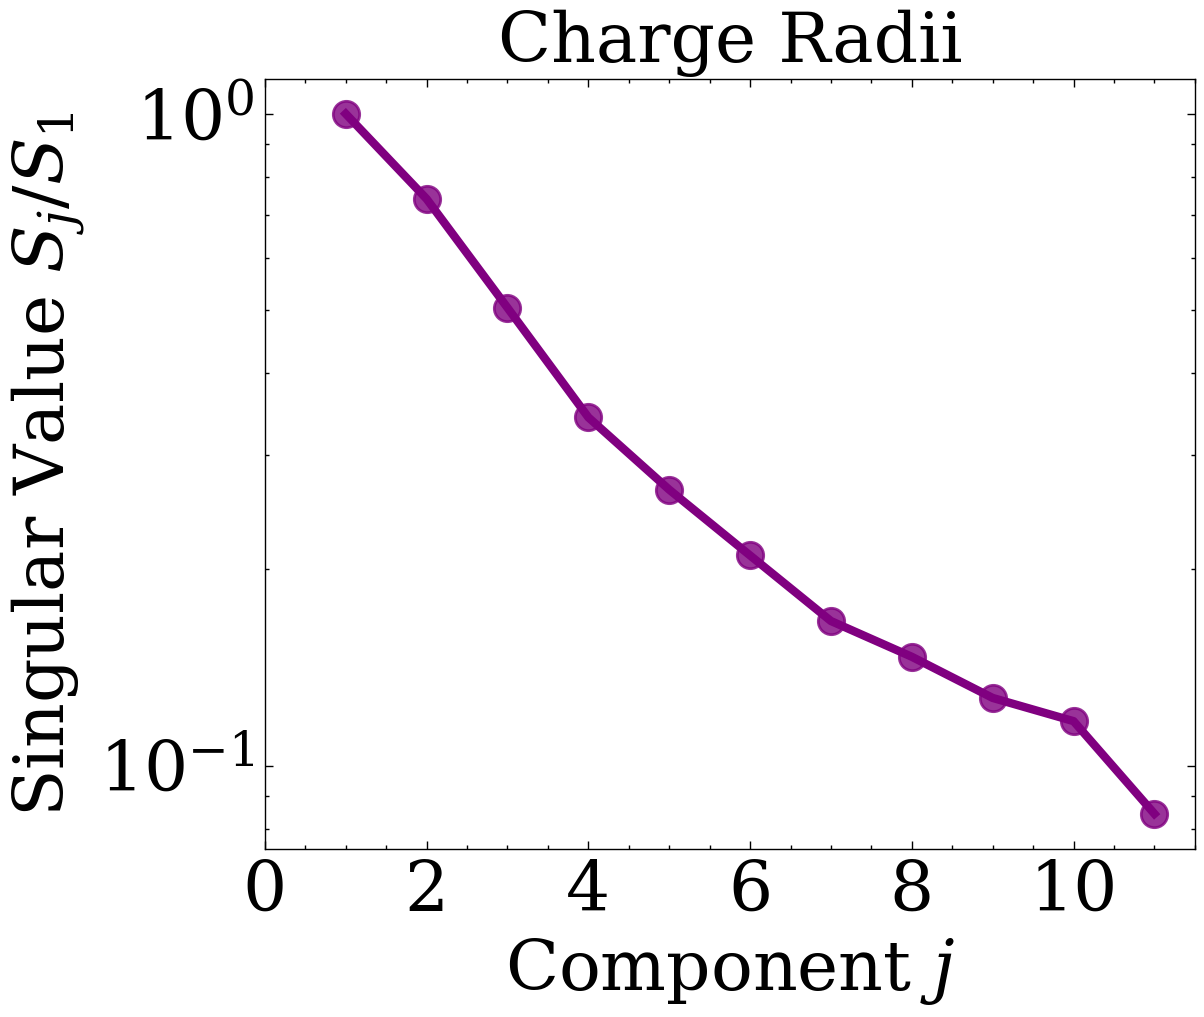

In [33]:
U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii', fontsize = 25)
# plt.savefig('Plots/Radii Data with Bailey/Singular values/Singular Values with FyDr and FyIVP.png')
plt.show()

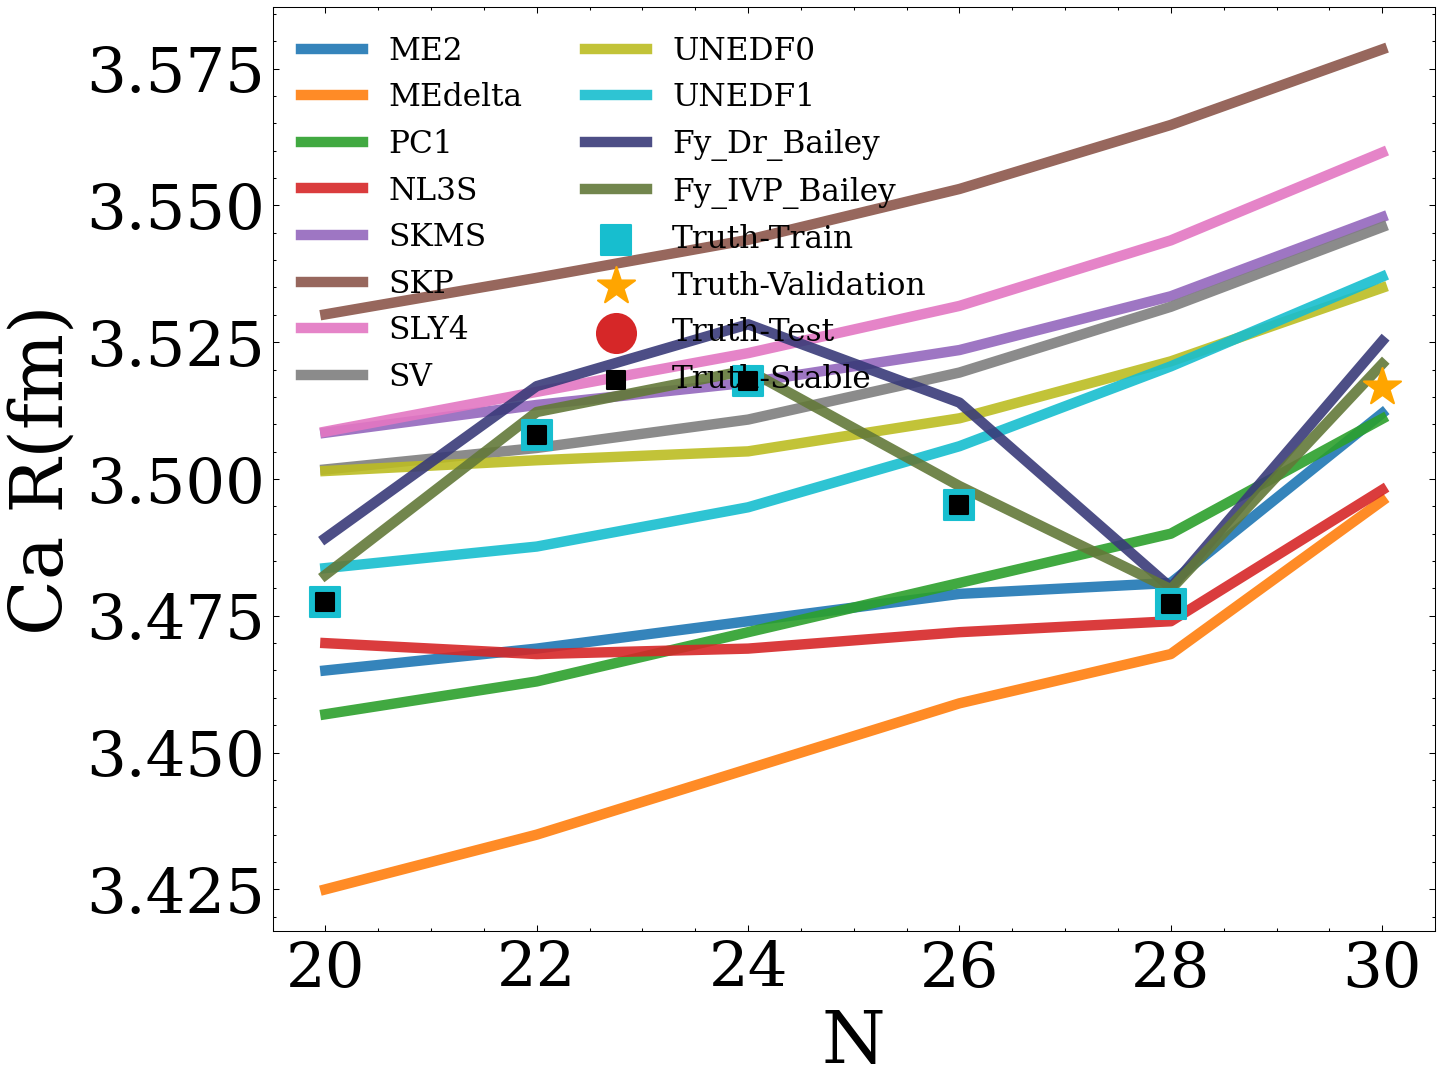

In [34]:
# I will graph the new models predictions for each isotope with all the models together
plot_model_predictions(filtered_models_output_radius_list_20, models_selected, 'Ca')
# plt.savefig('Plots/Radii data with Bailey/Models predictions/Ca predictions.png')
plt.show()

In [35]:
# This is a dictionary that contains all dataframes of models predictions and experimental data for each nuclei.
# We will use this to plot all predictions of models out and see their mismatch between experimental ones.

predictions_per_Z = filtered_predictions_all_elements(models_output_radius, \
                                    train_coordinates_radius, validation_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df)

In [38]:
def plot_predictions_grid_by_element(
    per_Z_data,        # dict[int -> dict[str -> pd.DataFrame]], from the builder above
    models_selected,   # list[str], model column names to plot as lines
    colors,            # list[str], same order/length as models_selected
    ncols=3,           # int, number of panels per row
    rows_per_fig=None, # int|None, paginate (#rows per page); None = one big figure
    sharey=False,      # bool, share y-axis across panels (per page)
    sharex = False,
    title='Charge radii predictions across elements',
    # savepattern=None   # str|None, 'Plots/All_page{page}.png' → saved per page
):
    # Basic guard: ensure we have at least one color per model
    if len(colors) < len(models_selected):
        raise ValueError('The number of colors must be bigger or equal than the number of models')

    # Collect and sort all Z values we have data for (stable plotting order).
    Zs = sorted(per_Z_data.keys())

    # Decide pagination. If rows_per_fig is None, then pages will then correspond to having all plots in 1 figures
    # Otherwise split Zs into chunks of size ncols * rows_per_fig.
    if rows_per_fig is None:
        pages = [Zs]
    else:
        per_fig = ncols * rows_per_fig
        pages = [Zs[i:i + per_fig] for i in range(0, len(Zs), per_fig)]

    # Iterate over pages; page is 1-based for friendly filenames/titles. page is jus the index of of the list of Z
    # for each figure. For example, if we want to include 15 figure per page, Z_chunk will contain those
    # corresponding 15 protons number and page will indicate the index of the page
    for page, Z_chunk in enumerate(pages, start=1):
        # Compute how many rows we need on this page (ceil division).
        nrows = int(np.ceil(len(Z_chunk) / ncols)) if len(Z_chunk) else 1

        # Create a grid of subplots. sharex=True aligns x-axes; sharey optional.
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols,
            figsize=(ncols * 5.0, nrows * 4.0),  # scale figure size with grid size
            dpi=150,
            sharex= sharex, sharey=sharey
        )

        # Ensure axes is always a 2D array so we can iterate reliably.
        axes = np.atleast_2d(axes)

        # Fill each panel with the corresponding Z’s data.
        # zip(axes.flat, Z_chunk) pairs each subplot with one Z until we run out.
        for ax, Z in zip(axes.flat, Z_chunk):
            # Unpack the five prebuilt slices for this Z.
            d = per_Z_data[Z]
            all_df   = d['all']     # full model predictions (columns 'N', model_i, ..., 'truth')
            train_df = d['train']   # truth points used for training
            val_df   = d['val']     # truth points for validation
            test_df  = d['test']    # truth points for test
            stab_df  = d['stable']  # truth points for stable isotopes

            # === Model lines ===
            # For each model name, take its column vs N from all_df, drop NaNs, sort by N, then plot.
            for i, model in enumerate(models_selected):
                sub = all_df[['N', model]].dropna().sort_values('N')
                ax.plot(
                    sub['N'], sub[model],
                    label=model,
                    color=colors[i],
                    alpha=0.9,
                    linewidth=2,
                    zorder=1
                )

            # === Experimental points overlays ===
            # Plot each split only if it has rows; each split uses its own marker/color,
            # which you already defined globally (color_train, marker_train, etc.).
            if train_df is not None and not train_df.empty:
                ax.scatter(
                    train_df["N"], train_df['truth'],
                    label="Truth-Train",
                    alpha=1, color=color_train,
                    s=40, marker=marker_train, zorder=2
                )
            if val_df is not None and not val_df.empty:
                ax.scatter(
                    val_df["N"], val_df['truth'],
                    label="Truth-Validation",
                    alpha=1, color=color_validation,
                    s=60, marker=marker_validation, zorder=2
                )
            if test_df is not None and not test_df.empty:
                ax.scatter(
                    test_df["N"], test_df['truth'],
                    label="Truth-Test",
                    alpha=1, color=color_test,
                    s=60, marker=marker_test, zorder=2
                )
            if stab_df is not None and not stab_df.empty:
                ax.scatter(
                    stab_df["N"], stab_df['truth'],
                    label="Truth-Stable",
                    alpha=1, color='k',
                    s=30, marker='s', zorder=2
                )

            # === Per-panel labels & cosmetics ===
            ax.set_title(f"Z={int(Z)}", fontsize=12)   # or swap in a Z→symbol map
            ax.set_xlabel("N", fontsize=12)
            ax.set_ylabel("R (fm)", fontsize=12)
            ax.grid(True, alpha=0.2)

        # If the last page doesn’t fill all subplots, hide the unused ones.
        total_axes = axes.size
        for k in range(len(Z_chunk), total_axes):
            axes.flat[k].set_visible(False)

        # === One global legend per figure (deduplicated) ===
        # Grab whatever labels/handles exist on the first subplot that has data.
        first_ax = next((a for a in axes.flat if a.has_data()), axes.flat[0])
        handles, labels = first_ax.get_legend_handles_labels()

        # Deduplicate entries by label text (later entries with same label are dropped).
        unique_by_label = dict(zip(labels, handles))

        # Place the legend above the grid; ncol controls how wide it spreads.
        fig.legend(
            unique_by_label.values(), unique_by_label.keys(),
            loc='upper center', ncol=min(6, len(unique_by_label)),
            fontsize=9, frameon=False
        )

        # Overall page title + layout.
        fig.suptitle(title, fontsize=16, y=0.98)
        # Reserve a bit of space at top for the legend/title.
        fig.tight_layout(rect=(0, 0, 1, 0.94))

        # # Save to disk if a pattern is provided. {page} becomes 1, 2, 3, ...
        # if savepattern:
        #     fig.savefig(savepattern.format(page=page), dpi=200, bbox_inches='tight')

        # Show the page now (useful when running interactively).
        # plt.show()

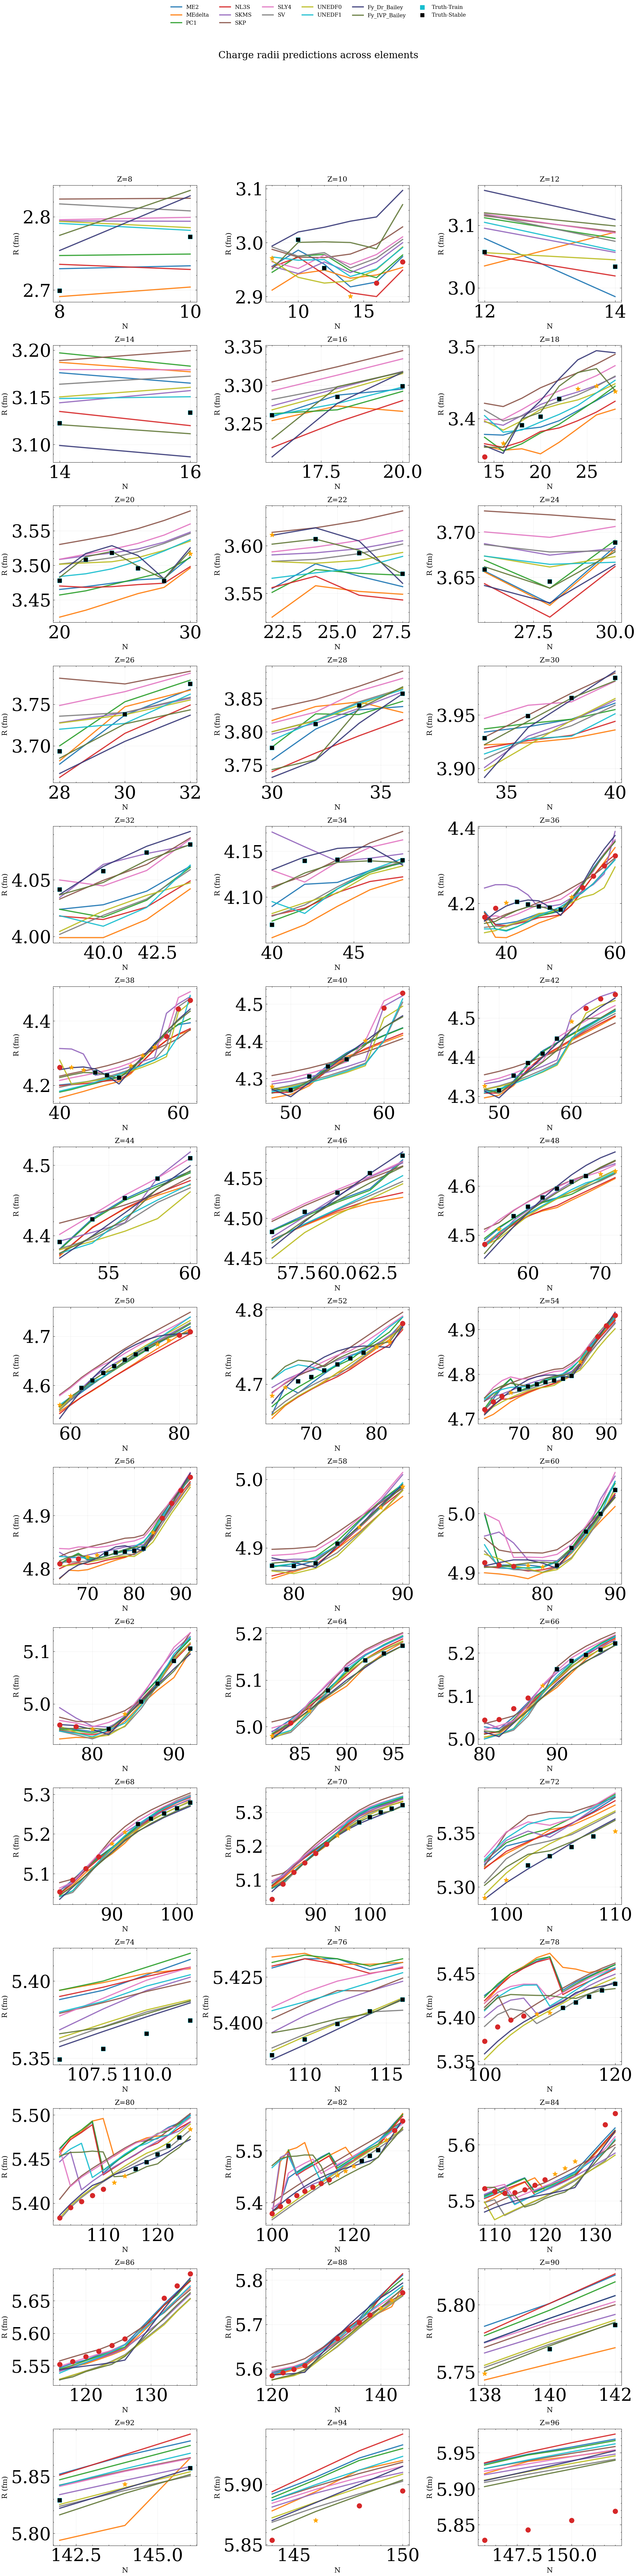

In [39]:
plot_predictions_grid_by_element(
    predictions_per_Z,        # dict[int -> dict[str -> pd.DataFrame]], from the builder above
    models_selected,   # list[str], model column names to plot as lines
    colors,            # list[str], same order/length as models_selected
    ncols=3,           # int, number of panels per row
    rows_per_fig=None, # int|None, paginate (#rows per page); None = one big figure
    sharey=False,      # bool, share y-axis across panels (per page)
    sharex = False,
    title='Charge radii predictions across elements',
    # savepattern=None   # str|None, 'Plots/All_page{page}.png' → saved per page
)

## Let's  now make the graph of the RMSE as the number of PCs increase

In [32]:
components_kept = 10
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [33]:
super_params_train = super_params(model_predictions_radius_train, models_output_radius_train['truth'])
supermodel_radius_train = super_params_train.dot(model_predictions_radius_train.T)
supermodel_radius_validation = super_params_train.dot(model_predictions_radius_validation.T)
supermodel_radius_test = super_params_train.dot(model_predictions_radius_test.T)
supermodel_radius_full = super_params_train.dot(model_predictions_radius.T)

supermodel_residuals_radius_train=supermodel_radius_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation= supermodel_radius_validation-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test = supermodel_radius_test-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full = supermodel_radius_full-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train=np.sqrt(np.sum(supermodel_residuals_radius_train**2) / len(supermodel_residuals_radius_train) )
supermodel_sigma_radius_validation=np.sqrt(np.sum(supermodel_residuals_radius_validation**2) / len(supermodel_residuals_radius_validation) )
supermodel_sigma_radius_test=np.sqrt(np.sum(supermodel_residuals_radius_test**2) / len(supermodel_residuals_radius_test) )
supermodel_sigma_radius_full=np.sqrt(np.sum(supermodel_residuals_radius_full**2) / len(supermodel_residuals_radius_full) )

In [34]:
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train, models_output_radius_list, model_predictions_radius_list, U, S, Vt)
        s_radius_all.append(res[0])
        s_radius_train.append(res[1])
        s_radius_validation.append(res[2])
        
        s_radius_test.append(res[3])

[0.08095491 0.07737723 0.08130466 0.07854563 0.0862466  0.08961173
 0.08756112 0.08396596 0.08279413 0.08290114 0.08465387 0.08408302]
0.015603854710109607
[0.05481218 0.02719076 0.03359086 0.08973036 0.09498497 0.00990112
 0.03145452 0.08288132 0.07815149 0.05749537 0.24555276 0.19425429]
0.013962688369986589
[ 0.12011793  0.01828943  0.08380239  0.11163277  0.09338824  0.02380579
  0.07149536 -0.00216946 -0.01873556  0.02546965  0.28060749  0.19229595]
0.013537308110048272
[ 0.11834086  0.02173036  0.08487105  0.10891918  0.09046586  0.02513383
  0.07190269 -0.00152588 -0.01983201  0.02451405  0.2815791   0.1939009 ]
0.013537023613515381
[ 0.08503918  0.21847887 -0.01096138  0.0421234   0.36171627 -0.01045756
  0.0841933  -0.10603737  0.00638045 -0.12416415  0.26762546  0.18606354]
0.01282560418085264
[ 0.35178918  0.19722279 -0.21286437  0.19405729  0.13827019  0.28055237
 -0.01635484 -0.11105294  0.28151016 -0.58564842  0.27655472  0.20596387]
0.011099384186787511
[ 0.49517329  0.1

In [35]:
len(s_radius_validation)

12

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
C:\Users\congn\AppData\Local\Temp\ipykernel_2232\509779441.py:14: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')
C:\Users\congn\AppData\Local\Temp\ipykernel_2232\509779441.py:17: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")
C:\Users\congn\AppData\Local\Temp\ipykernel_2232\509779441.py:21: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],co

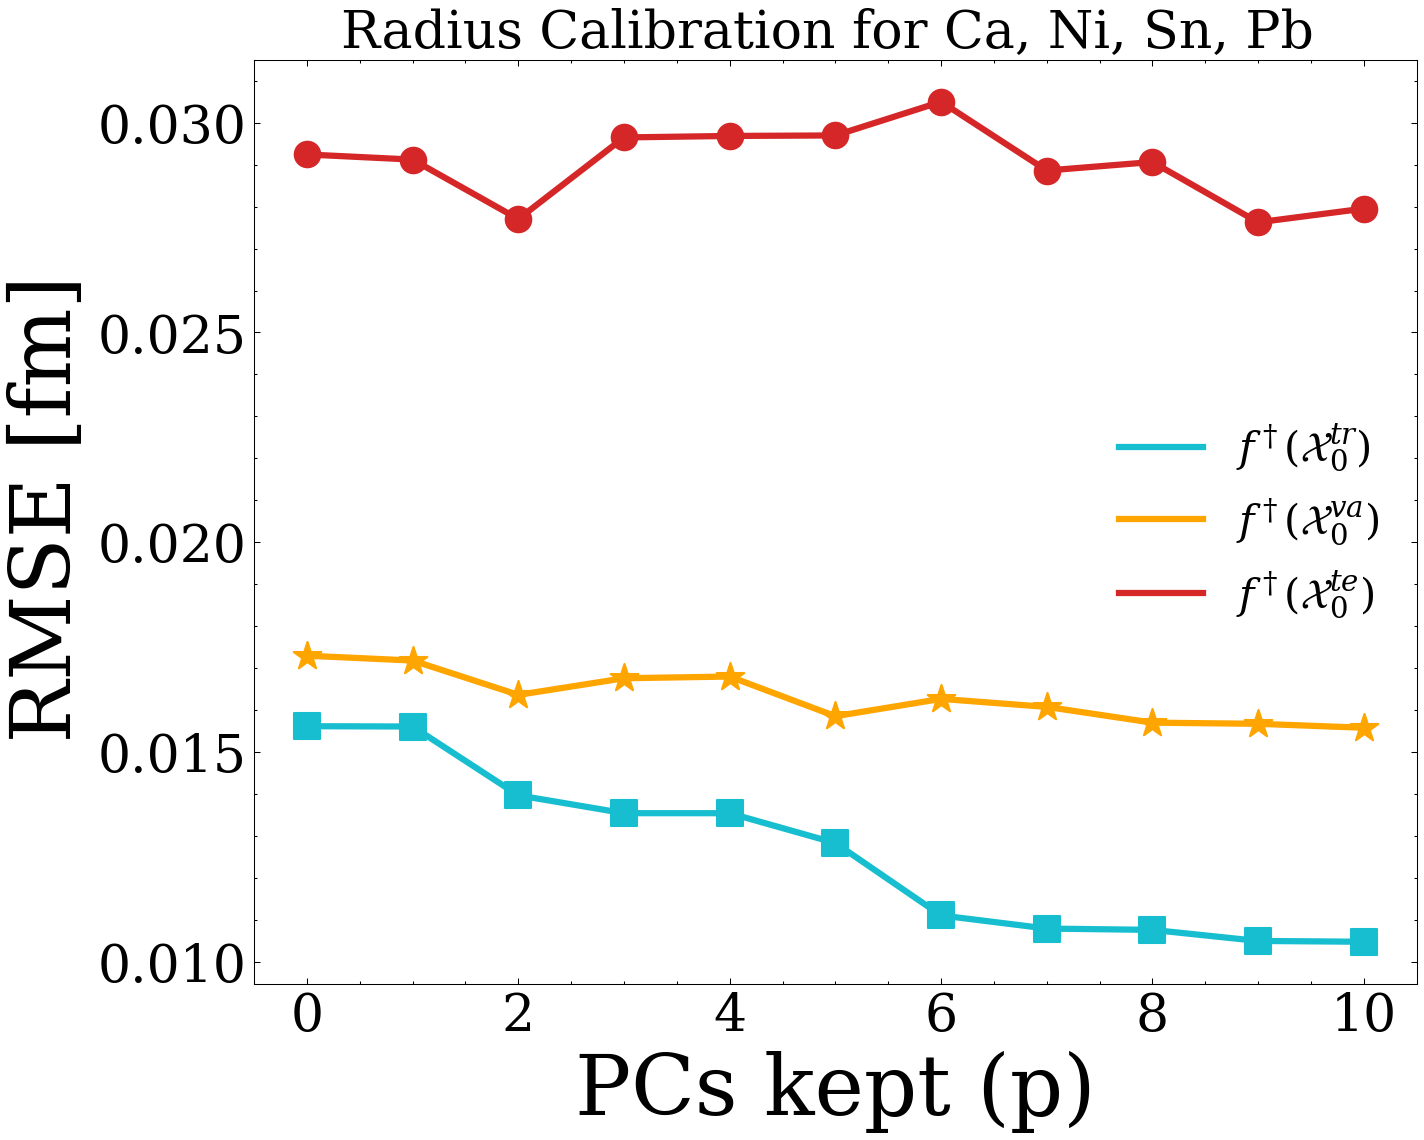

In [36]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
ax.set_xticks([0,2,4,6,8, 10])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration for Ca, Ni, Sn, Pb ', fontsize = 25)
# plt.savefig('Plots/Radii data with Bailey/RMSE decays/Radius RMSE decays with FyDr and FyIVP.png')
# plt.legend(fontsize=30)
plt.show()

In [37]:
def models_RMSE_radius_calculator(models_selected):
    models_RMSE_train = []
    models_RMSE_validation = []
    models_RMSE_test = []
    models_RMSE_full = []

    for model in models_selected:
        residuals_train=models_output_radius_train[model]-models_output_radius_train['truth'].tolist()
        residuals_validation= models_output_radius_validation[model]-models_output_radius_validation['truth'].tolist()
        residuals_test = models_output_radius_test[model]-models_output_radius_test['truth'].tolist()
        residuals_full = models_output_radius[model]-models_output_radius['truth'].tolist()
    
        sigma_train=np.sqrt(np.sum(residuals_train**2) / len(residuals_train) )
        sigma_validation=np.sqrt(np.sum(residuals_validation**2) / len(residuals_validation) )
        sigma_test=np.sqrt(np.sum(residuals_test**2) / len(residuals_test) )
        sigma_full=np.sqrt(np.sum(residuals_full**2) / len(residuals_full) )

        models_RMSE_train.append(sigma_train)
        models_RMSE_validation.append(sigma_validation)
        models_RMSE_test.append(sigma_test)
        models_RMSE_full.append(sigma_full)
        
    return models_RMSE_train, models_RMSE_validation, models_RMSE_test, models_RMSE_full

In [38]:
models_RMSE_radius_train, models_RMSE_radius_validation, models_RMSE_radius_test, models_RMSE_radius_full = models_RMSE_radius_calculator(models_selected)

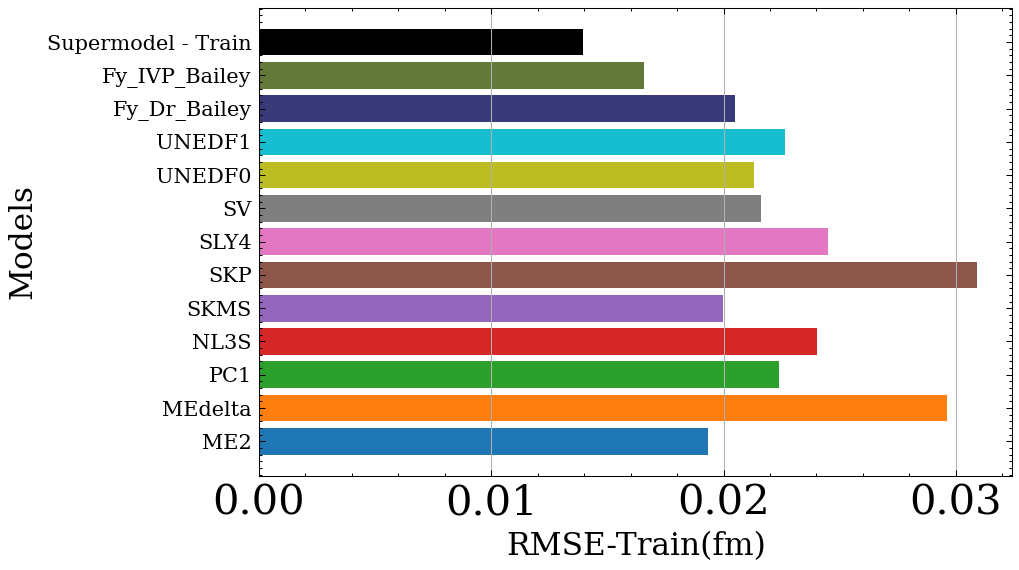

In [39]:
y_max = 0.05

# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Train region
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4), dpi=150)
i = 0
for model in (models_selected):
    plt.barh(model, models_RMSE_radius_train[i], color=colors[i])
    i += 1
plt.barh('Supermodel - Train', s_radius_train[2], color='k')

plt.xlabel('RMSE-Train(fm)', fontsize=15)
plt.ylabel('Models', fontsize=15)
plt.yticks(fontsize=10)
plt.grid(axis='x')
plt.tight_layout()
# plt.savefig('Plots/Radii data with Bailey/Models RMSE/Models RMSE train with FyDr and FyIVP.png')
plt.show()

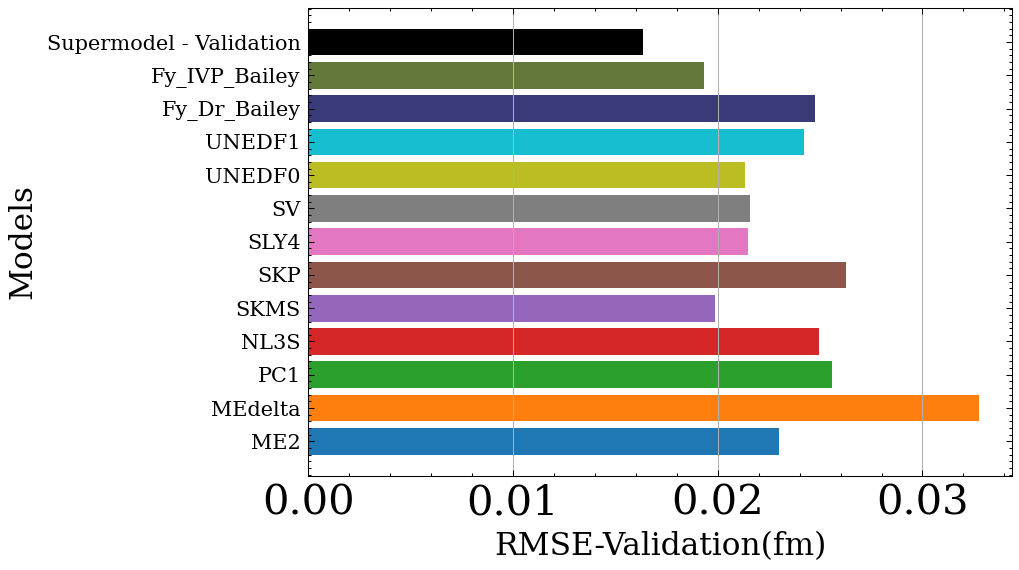

In [40]:
y_max = 0.05

# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Train region
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4), dpi=150)
i = 0
for model in (models_selected):
    plt.barh(model, models_RMSE_radius_validation[i], color=colors[i])
    i += 1
plt.barh('Supermodel - Validation', s_radius_validation[2], color='k')

plt.xlabel('RMSE-Validation(fm)', fontsize=15)
plt.ylabel('Models', fontsize=15)
plt.yticks(fontsize=10)
plt.grid(axis='x')
plt.tight_layout()
# plt.savefig('Plots/Radii data with Bailey/Models RMSE/Models RMSE validation with FyDr and FyIVP.png')
plt.show()

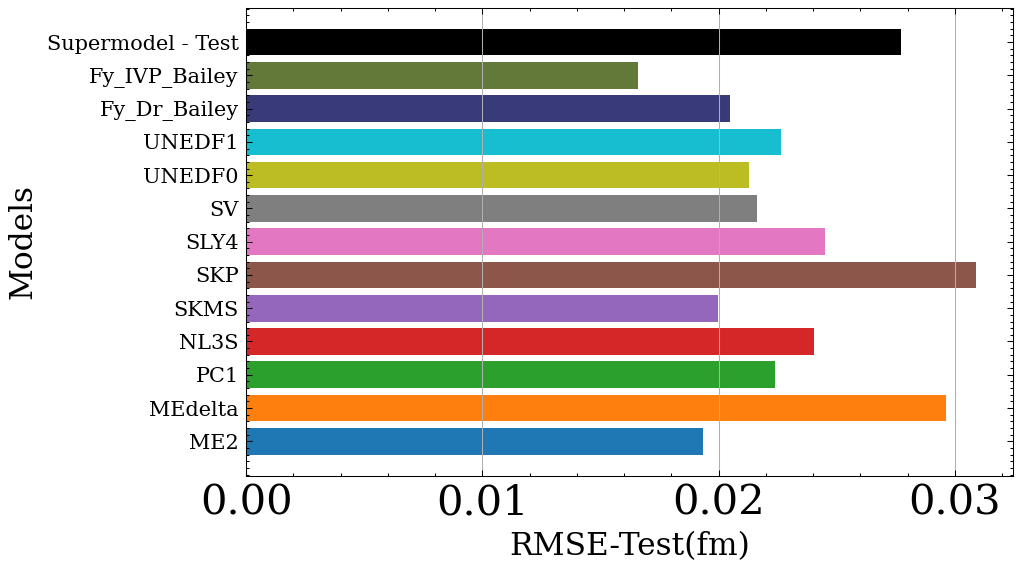

In [41]:
y_max = 0.05

# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Train region
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4), dpi=150)
i = 0
for model in (models_selected):
    plt.barh(model, models_RMSE_radius_train[i], color=colors[i])
    i += 1
plt.barh('Supermodel - Test', s_radius_test[2], color='k')

plt.xlabel('RMSE-Test(fm)', fontsize=15)
plt.ylabel('Models', fontsize=15)
plt.yticks(fontsize=10)
plt.grid(axis='x')
plt.tight_layout()
# plt.savefig('Plots/Radii data with Bailey/Models RMSE/Models RMSE test with FyDr and FyIVP.png')
plt.show()

In [42]:
components_kept = 2
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])

In [43]:
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [44]:
super_PC_weights_radius = super_params(models_PC_radius_train.iloc[:,4:].values, y_radius)
print(np.dot(super_PC_weights_radius, Vt_hat))
model_weights_radius = np.dot(super_PC_weights_radius, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
model_weights_radius = np.array(model_weights_radius)
naive_supermodel_radius = model_predictions_radius.dot(model_weights_radius)
naive_supermodel_radius_dict = {'N' : models_output_radius['N'], 'Z': models_output_radius['Z'], 'naive supermodel' : naive_supermodel_radius}
naive_supermodel_radius_df = pd.DataFrame(naive_supermodel_radius_dict)
naive_supermodel_radius_df

[-0.02852116 -0.05614257 -0.04974248  0.00639702  0.01165163 -0.07343221
 -0.05187881 -0.00045201 -0.00518184 -0.02583796  0.16221942  0.11092096]


,N,Z,naive supermodel
0,8,8,2.769229
1,10,8,2.797512
2,8,10,2.968034
3,10,10,2.983042
4,12,10,2.984002
...,...,...,...
340,150,94,5.915438
341,146,96,5.916358
342,148,96,5.929026
343,150,96,5.940641


### Bayesian Analysis

In [45]:
X_train = U_hat.copy()

In [46]:
nu0_chosen=1
sigma20_chosen=0.03

In [47]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)
    n = len(y) # We are still taking mass and radius to be the same size
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2 = np.sum(residuals**2) / len(residuals) 
    cov_matrix = sigma2 * X_T_X_inv
    
    samples = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X/sigma2
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(        b_mean_cov_inv.dot(b_mean_prior)+ X.T.dot(y)/sigma2  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel=X.dot(b_current)
        
        residuals = y - supermodel 
        
        
        shape_post = (nu0 + n)/2.
        scale_post = (nu0*sigma20 + np.sum(residuals**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))
    


    return np.array(samples)

In [48]:
samples = gibbs_sampler(y_radius,X_train, 100000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\congn\AppData\Local\Temp\ipykernel_2232\3057479877.py:2: SyntaxWarning: invalid escape sequence '\s'
  label_global.append(f'$\sigma$')


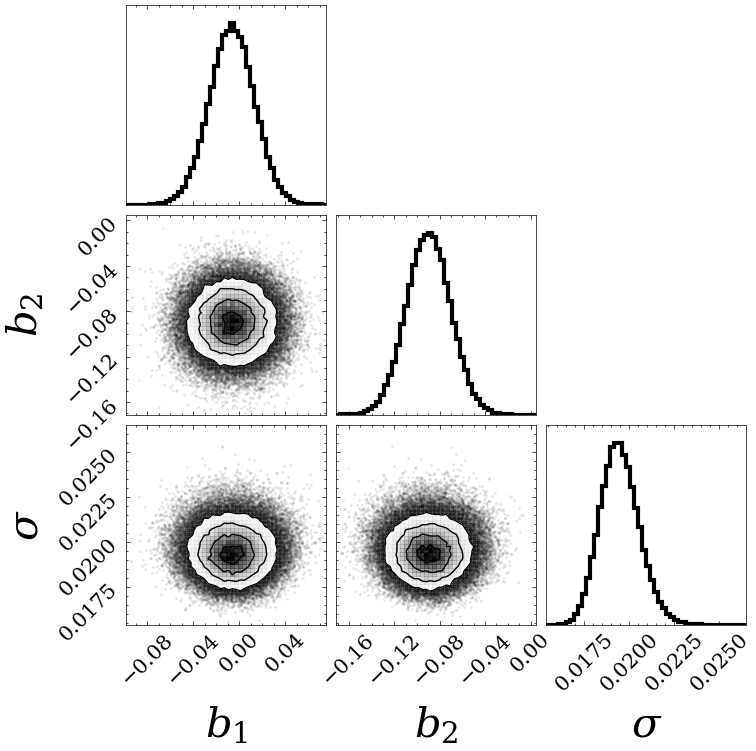

In [49]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
# plt.savefig('Plots/Radii data with Bailey/Corner plots/Unconstrained corner plot 2PCs with FyDr and FyIVP.png')
plt.show()

In [50]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights= np.array(model_weights)

In [51]:
filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

filtered_models_output_radius_28 = filtered_models_output_radius_list_28[0]
filtered_model_predictions_radius_28 = filtered_models_output_radius_28.iloc[:,3:-1].values

filtered_models_output_radius_50 = filtered_models_output_radius_list_50[0]
filtered_model_predictions_radius_50 = filtered_models_output_radius_50.iloc[:,3:-1].values

filtered_models_output_radius_82 = filtered_models_output_radius_list_82[0]
filtered_model_predictions_radius_82 = filtered_models_output_radius_82.iloc[:,3:-1].values

In [52]:
rndm_20, [lower_radius_20, median_radius_20, upper_radius_20] = rndm_m_random_calculator(filtered_model_predictions_radius_20, samples, Vt_hat)
rndm_82, [lower_radius_82, median_radius_82, upper_radius_82] = rndm_m_random_calculator(filtered_model_predictions_radius_82, samples, Vt_hat)
rndm_28, [lower_radius_28, median_radius_28, upper_radius_28] = rndm_m_random_calculator(filtered_model_predictions_radius_28, samples, Vt_hat)
rndm_50, [lower_radius_50, median_radius_50, upper_radius_50] = rndm_m_random_calculator(filtered_model_predictions_radius_50, samples, Vt_hat)

In [61]:
type(models_output_radius['N'])

pandas.core.series.Series

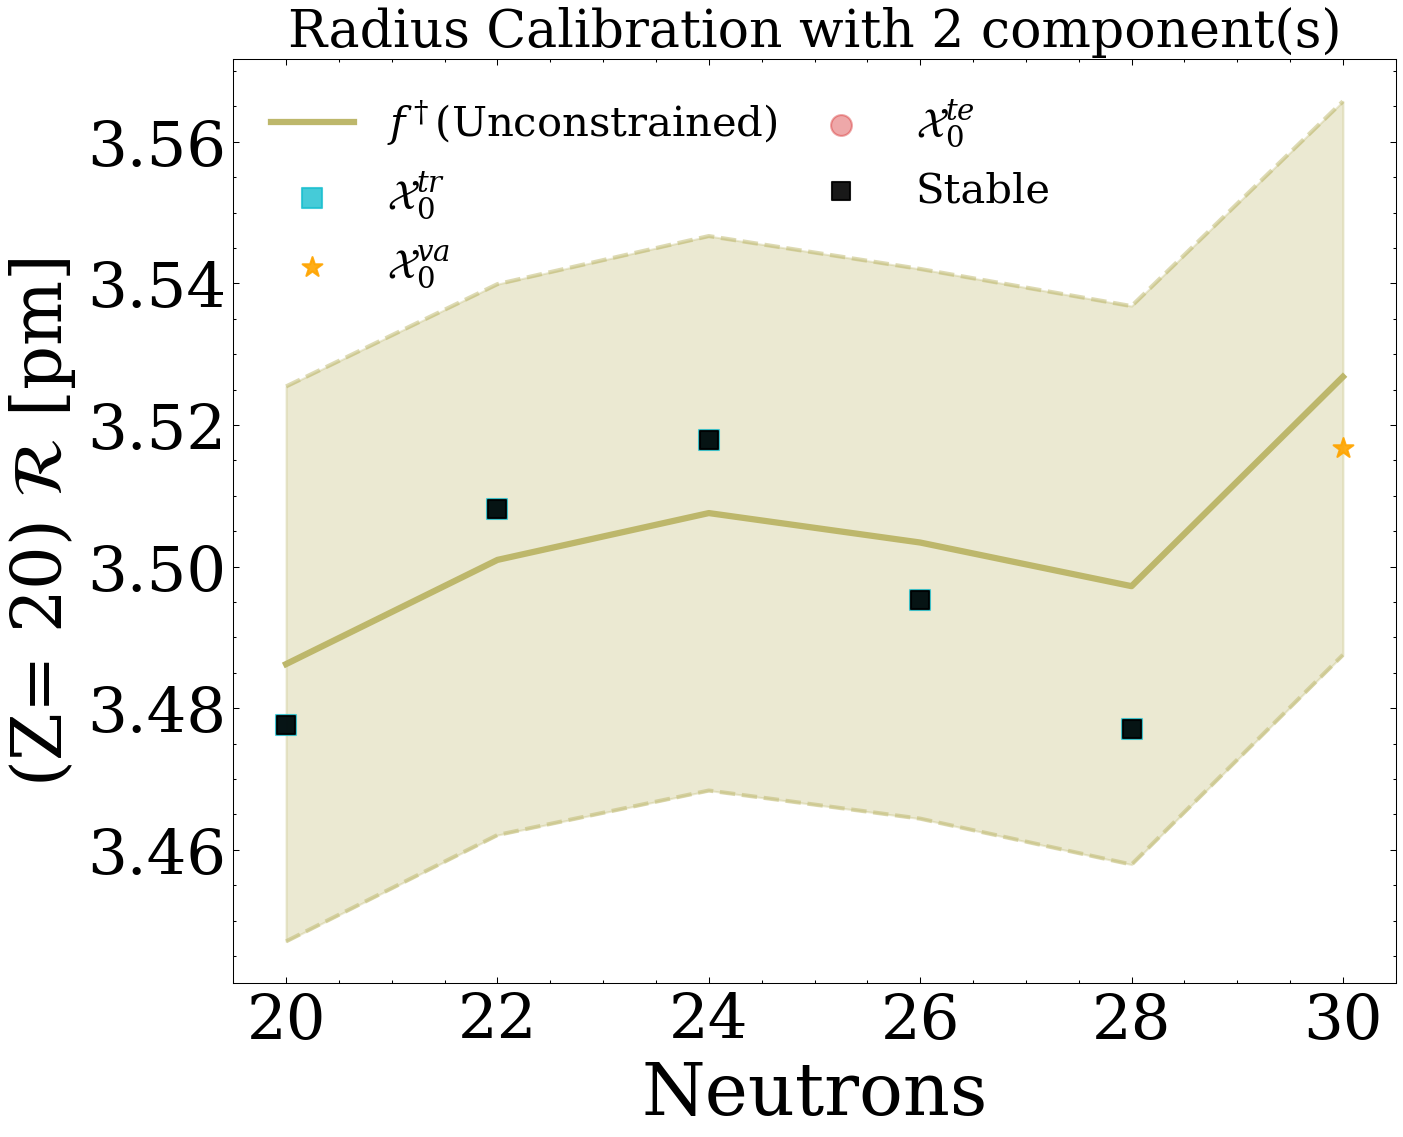

In [53]:
supermodel_predictions_radius_range_20 = [lower_radius_20, median_radius_20, upper_radius_20]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_20, filtered_models_output_radius_list_20, filtered_models_output_radius_stable_20, 20, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Ca 20 - Unconstrained BMM with {components_kept} components - Fy_Dr and Fy_IVP' )
plt.show()

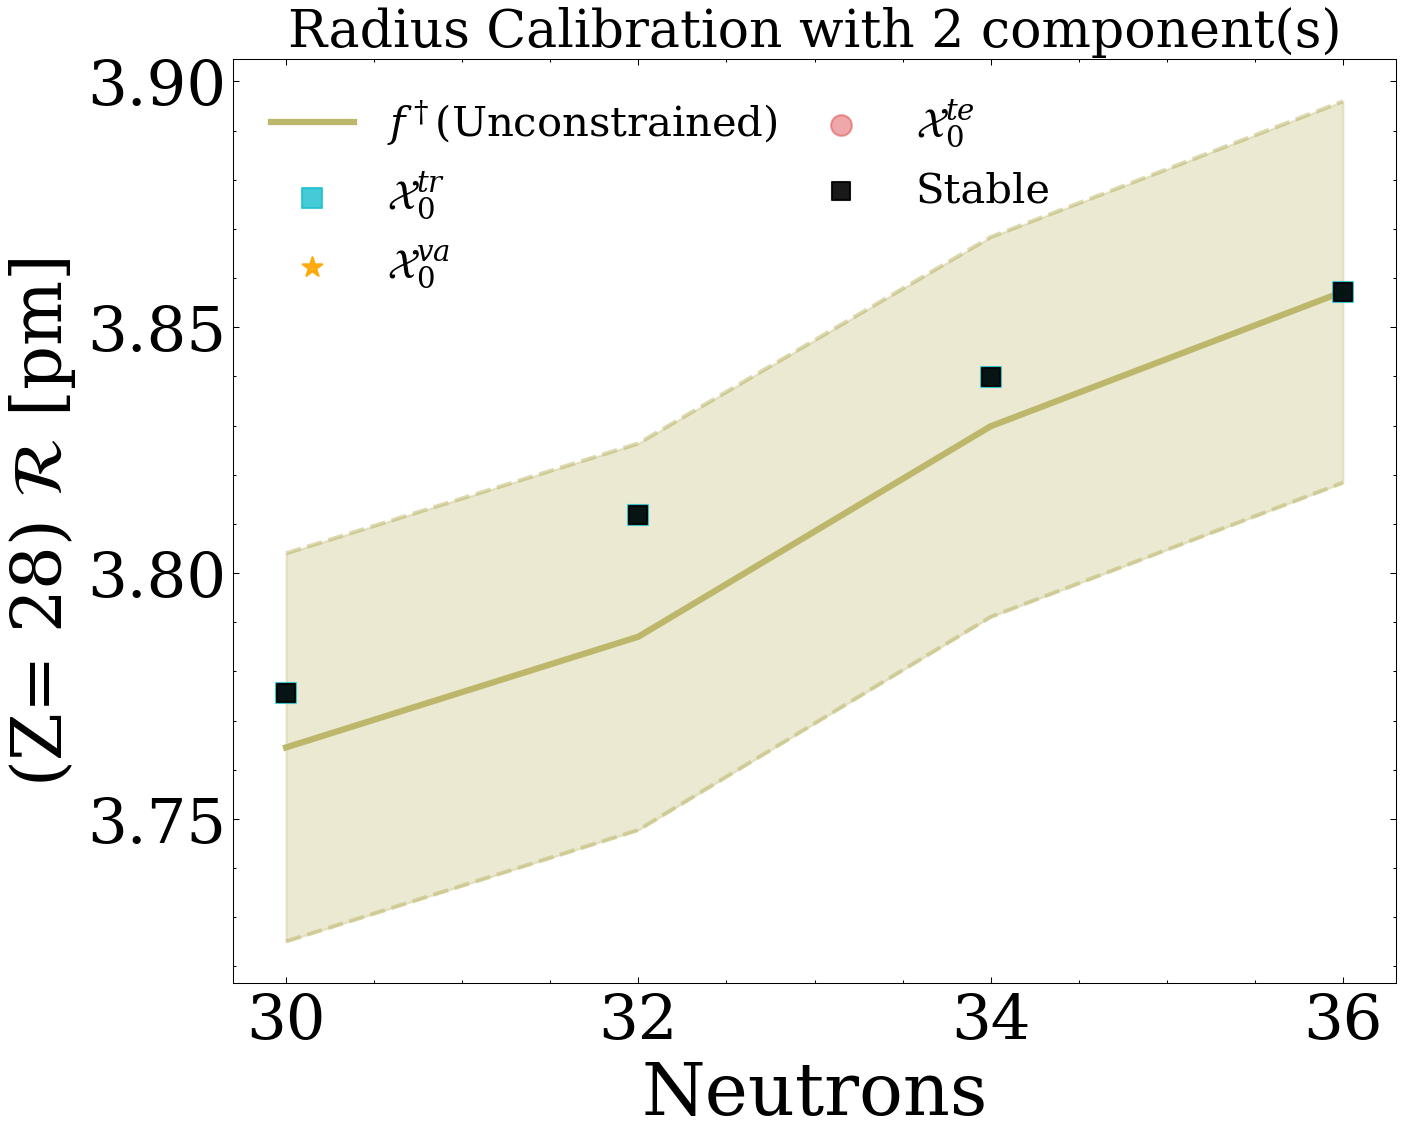

In [54]:
supermodel_predictions_radius_range_28 = [lower_radius_28, median_radius_28, upper_radius_28]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_28, filtered_models_output_radius_list_28, filtered_models_output_radius_stable_28, 28, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Ni 28 - Unconstrained BMM with {components_kept} components - Fy_Dr and Fy_IVP')
plt.show()

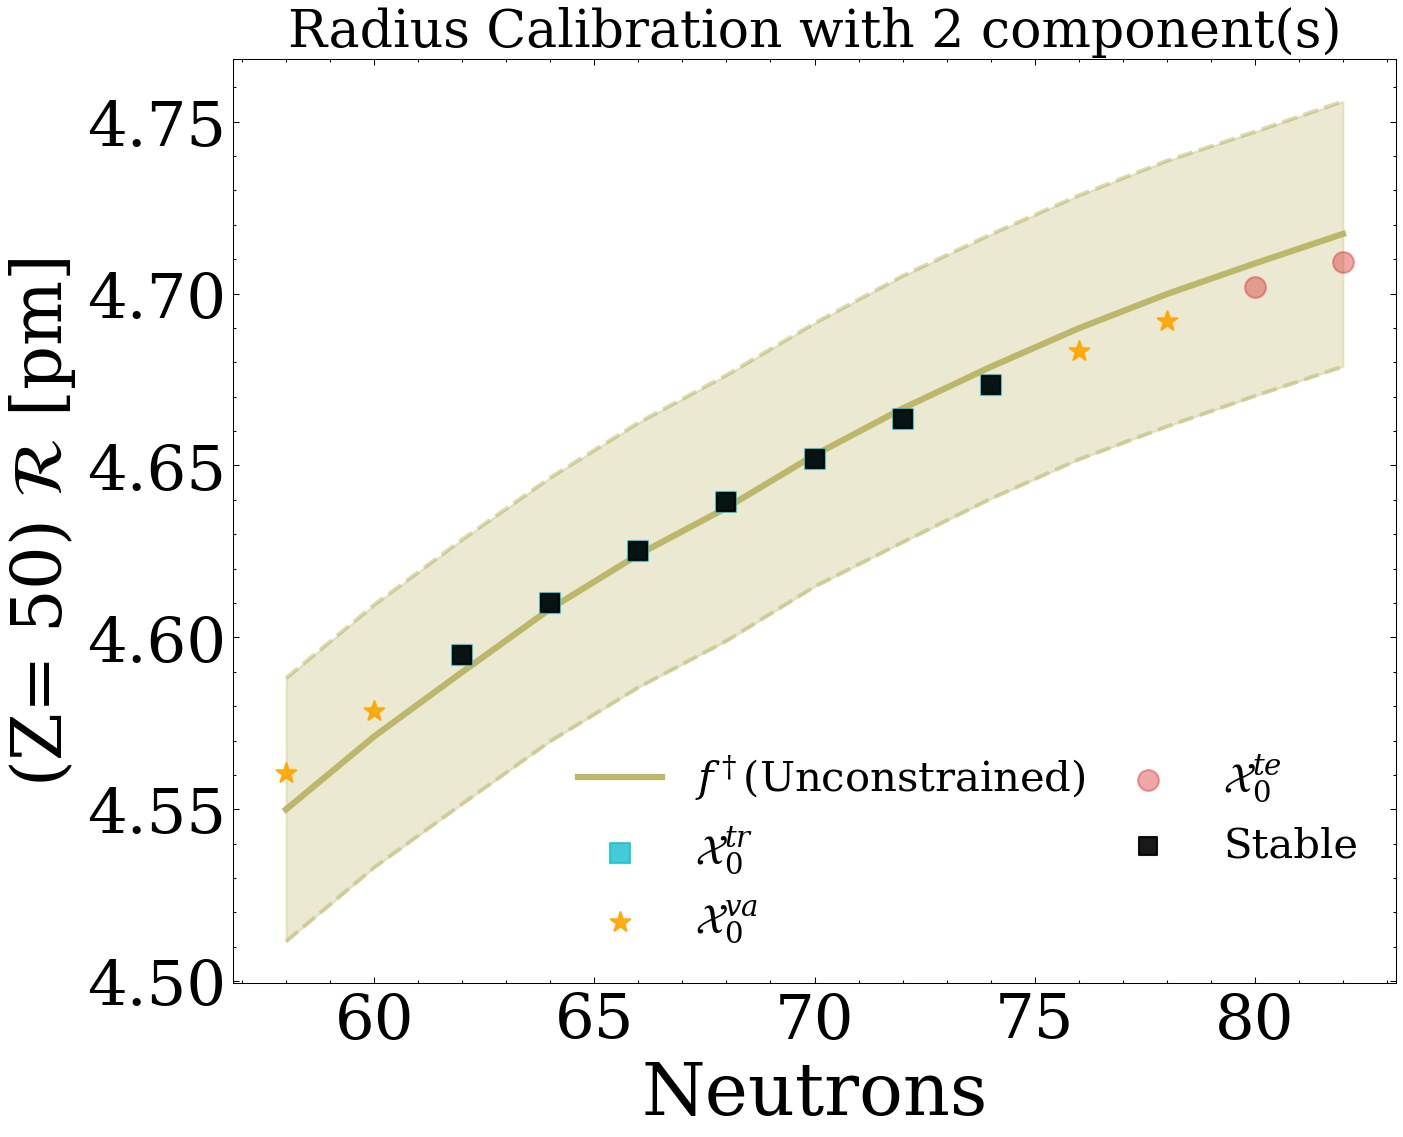

In [55]:
supermodel_predictions_radius_range_50 = [lower_radius_50, median_radius_50, upper_radius_50]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_50, filtered_models_output_radius_list_50, filtered_models_output_radius_stable_50, 50, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Zn 50 - Unconstrained BMM with {components_kept} components - - Fy_Dr and Fy_IVP')
plt.show()

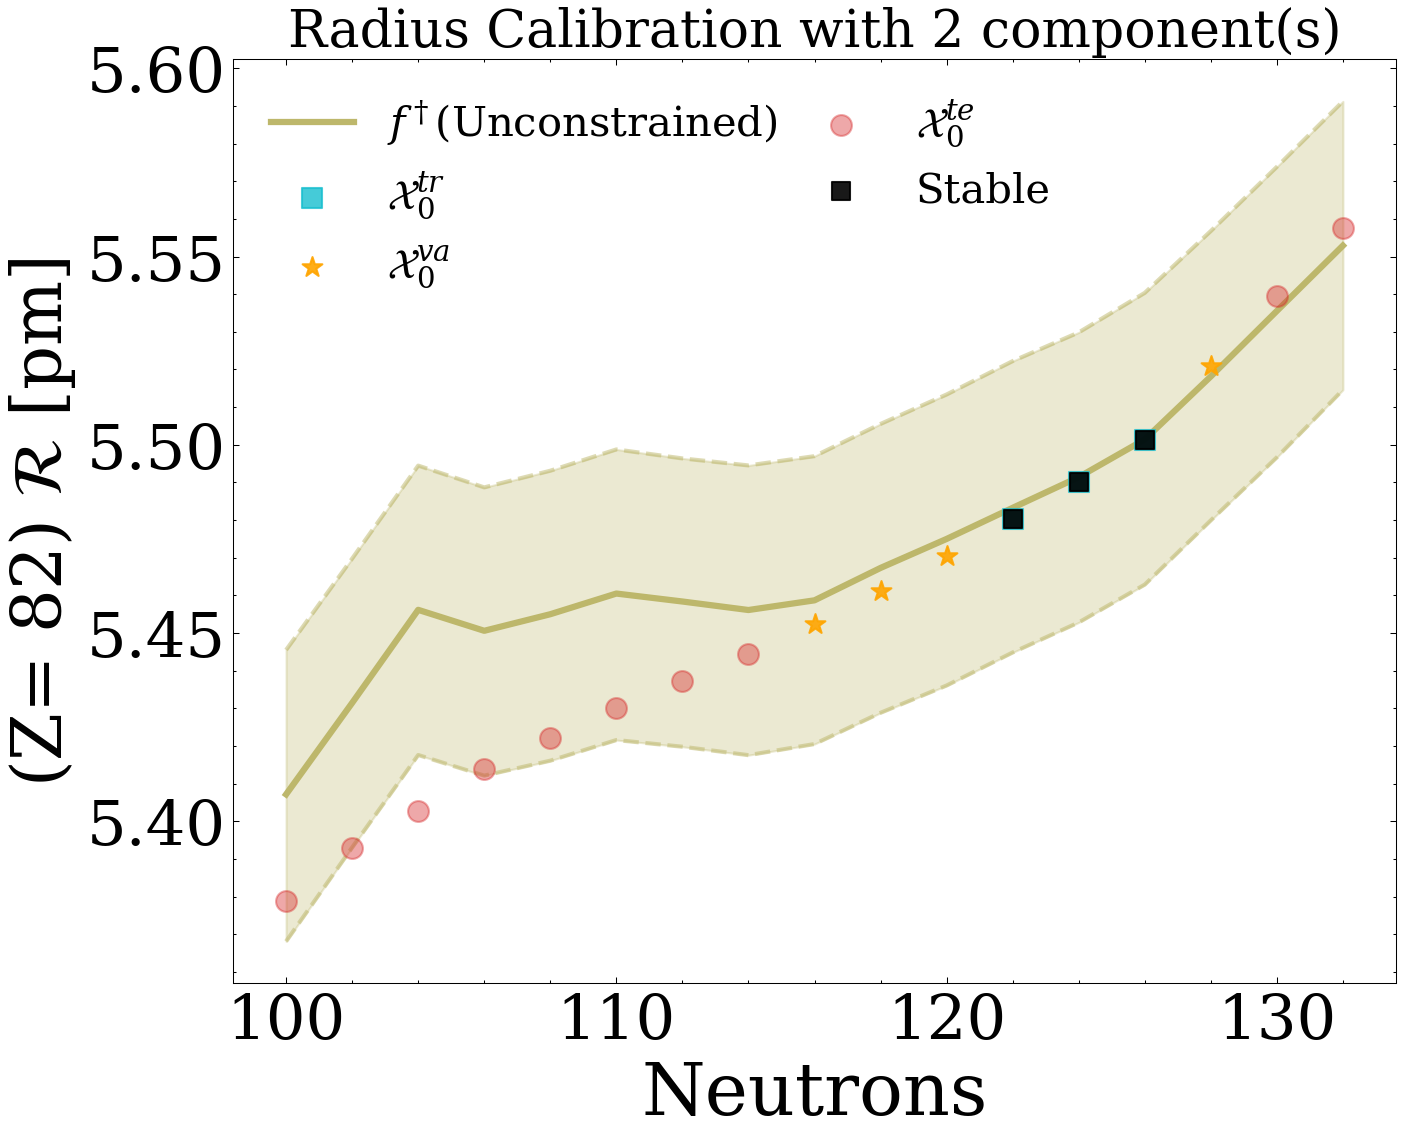

In [56]:
supermodel_predictions_radius_range_82 = [lower_radius_82, median_radius_82, upper_radius_82]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_82, filtered_models_output_radius_list_82, filtered_models_output_radius_stable_82, 82, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Pb 82 - Unconstrained BMM with {components_kept} components - Fy_Dr and Fy_IVP.png')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
C:\Users\congn\AppData\Local\Temp\ipykernel_2232\3889116182.py:21: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega_k$',fontsize=35)


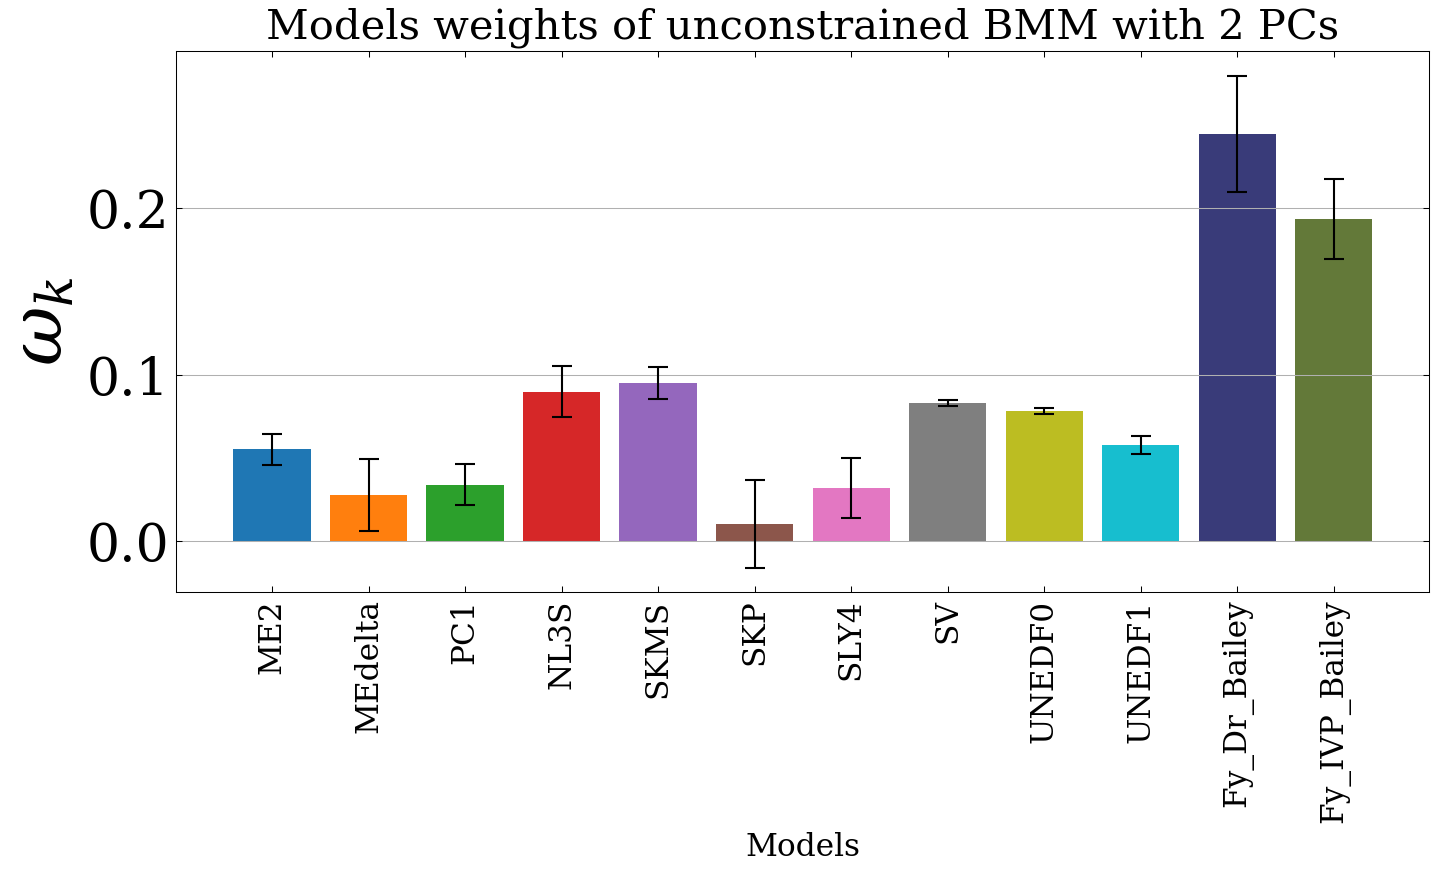

In [57]:
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
# labels=list(models_output.keys())
plt.figure(figsize=(10, 6),dpi=150)
# y_max=0.6


i=0
for model in models_selected:
        
        # ax.plot(filtered_models_output["N"], filtered_models_output[key_list[model_index]], 
        #         label = n_Labels[class_index], color=colors[class_index],alpha = alpha_models,linewidth=5)
        # plt.bar(model , np.mean(samples_naive_space_sigma.T[i]), color=colors[i])
        plt.bar(model , np.mean(model_weights.T[i]),yerr=np.std(model_weights.T[i]), color=colors[i],capsize=5)
        i=i+1

plt.minorticks_off()


plt.xlabel('Models',fontsize=15)
plt.ylabel('$\omega_k$',fontsize=35)
# plt.ylim(-0.2,0.5)
# plt.yticks([0, 0.2, 0.4])
plt.xticks(fontsize=15,rotation='vertical')
plt.yticks(fontsize=25)
plt.grid(axis='y')
plt.title(f'Models weights of unconstrained BMM with {components_kept} PCs', fontsize= 20)
plt.tight_layout()
# plt.savefig(f'Plots/Radii Data with Bailey/Models weights/Uncontrained BMM models weights with {components_kept} PCs')
plt.show()

### We have observed that even though sometimes the mean predictions of the models aree close the experimental data, the error bars that we have are very big. To understand how this happened, we can think of a simple scenerio in our head: suppose you have some data point that you want to fit a linear function to. Suppose in those data points, there is an outlier that just really far away from our predictions. If we were to model our errors with a gaussian distribution, then those point could try to overfit our errors, therefore making the error bar very big even though we do not need such error. To check whether this is the case, we want to plot out the models predictions and experimental data and see whether there are outliers in our models space.

In [ ]:
def filtered_predictions_multiple_elements(
    models_output: pd.DataFrame,
    train_idx, val_idx, test_idx,
    stable_coordinates,
    Zs: list[int] | None = None,
    N_min: int = 0,
    N_max: int = 300,
):
    """
    Return a dict keyed by Z with all the filtered DataFrames you need for plotting.

    For each element Z, the value is a dict:
        {
          'all':  df_all,          # all model curves for that Z, N in [N_min, N_max]
          'train': df_train,       # truth points used for training, restricted to that Z
          'val':   df_val,         # truth points used for validation, restricted to that Z
          'test':  df_test,        # truth points used for testing, restricted to that Z
          'stable': df_stable      # truth points for stable isotopes (Z-fixed)
        }

    Notes:
    - Uses your existing per-element extractors to keep behavior identical.
    - Sorts each DF by N for nice lines/ordering downstream.
    - Zs=None → all unique Z present in `models_output`.
    """
    # Decide which Z to process
    if isotopes is None:
        isotopes = sorted(models_output['Z'].unique())

    out = {}
    for Z in isotopes:
        # Reuse your extractors to preserve logic & indexing semantics
        filtered_models_list = filtered_models_output_extraction(
            Selected_element=Z,
            models_output=models_output,
            train_coordinates=train_idx,
            validation_coordinates=val_idx,
            test_coordinates=test_idx
        )
        df_all, df_train, df_val, df_test = filtered_models_list

        df_stable = filtered_models_output_stable_extraction(
            Selected_element=Z,
            models_output=models_output,
            stable_coordinates=stable_coordinates
        )

        # (Optional) safety: enforce N-range & sorting
        def clip_sort(df):
            if df is None or len(df) == 0: 
                return df
            df = df.loc[df['N'].between(N_min, N_max)].copy()
            df.sort_values('N', inplace=True)
            return df

        dictionary[Z] = {
            'all':    clip_sort(df_all),
            'train':  clip_sort(df_train),
            'val':    clip_sort(df_val),
            'test':   clip_sort(df_test),
            'stable': clip_sort(df_stable)
        }

    return dictionary

In [58]:
bias0=np.full(len(model_predictions_radius_train.T),1/len(model_predictions_radius_train.T))
#This term will be added to the \omegas when obtaining them from the \betas to account for centering the data

In [59]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn=10000,stepsize=0.001):
    if centering_data == False:
        print("Only available for centering data")
        return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)
    
    n = len(y)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X),0)

    
    
    supermodel_current=X.T.dot(b_current)
    

    residuals_current = y - supermodel_current 

    
  
    log_likelihood_current= -np.sum(residuals_current**2)
    
    
    sigma2 = -log_likelihood_current/ len(residuals_current) 

    
    
    samples = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed

        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed
                acceptance=acceptance+1

        shape_post = (nu0 + n)/2.
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))        
        
        
        
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return np.array(samples)

In [60]:
%%time
samples_simplex=gibbs_sampler_simplex(y_radius, X_train.T, 500000,[nu0_chosen, sigma20_chosen],burn=100000,stepsize=0.06)

percentage accepted: 20
CPU times: total: 3min 54s
Wall time: 3min 58s


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\congn\AppData\Local\Temp\ipykernel_14468\2498768286.py:2: SyntaxWarning: invalid escape sequence '\s'
  label_global.append(f'$\sigma$')


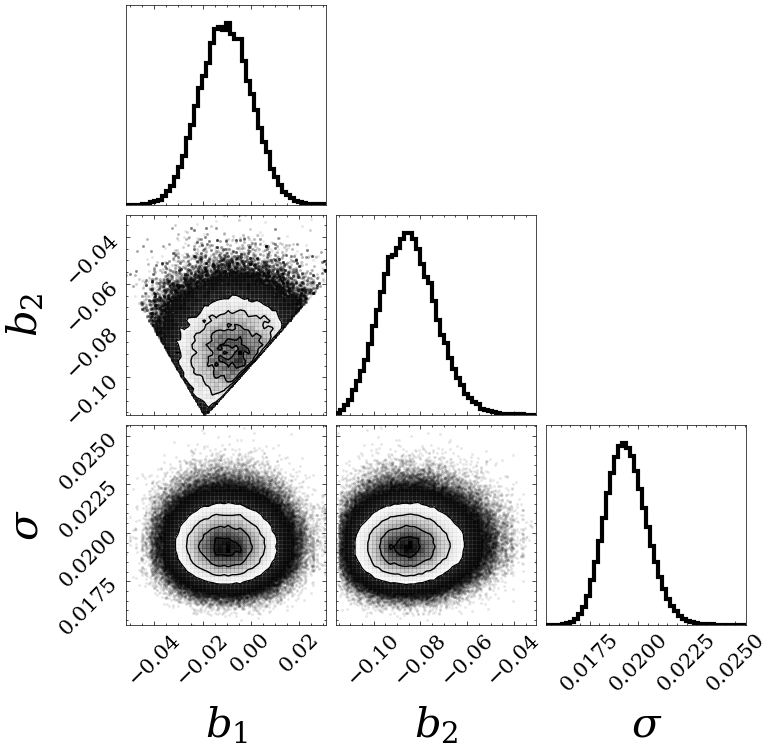

In [61]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples_simplex,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
# plt.savefig('Plots/Radii data with Bailey/Corner plots/Simplex corner plot 2PCs with FyDr and FyIVP.png')
plt.show()

In [62]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights_simplex = []
for beta_simplex in samples_simplex:
    model_weights_simplex.append(np.dot(beta_simplex[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex= np.array(model_weights_simplex)

In [63]:
rndm_simplex_20, [lower_radius_simplex_20, median_radius_simplex_20, upper_radius_simplex_20] = rndm_m_random_calculator(filtered_model_predictions_radius_20, samples_simplex, Vt_hat)
rndm_simplex_28, [lower_radius_simplex_28, median_radius_simplex_28, upper_radius_simplex_28] = rndm_m_random_calculator(filtered_model_predictions_radius_28, samples_simplex, Vt_hat)
rndm_simplex_50, [lower_radius_simplex_50, median_radius_simplex_50, upper_radius_simplex_50] = rndm_m_random_calculator(filtered_model_predictions_radius_50, samples_simplex, Vt_hat)
rndm_simplex_82, [lower_radius_simplex_82, median_radius_simplex_82, upper_radius_simplex_82] = rndm_m_random_calculator(filtered_model_predictions_radius_82, samples_simplex, Vt_hat)


In [64]:
supermodel_predictions_radius_range_simplex_20 = [lower_radius_simplex_20, median_radius_simplex_20, upper_radius_simplex_20]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel_simplex(supermodel_predictions_radius_range_simplex_20, filtered_models_output_ radius_list_20, filtered_models_output_radius_stable_20, 20, 'pm', 'R', 'Simplex', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Ca 20 - Simplex BMM with {components_kept} components - Fy_Dr and Fy_IVP' )
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2429657421.py, line 4)

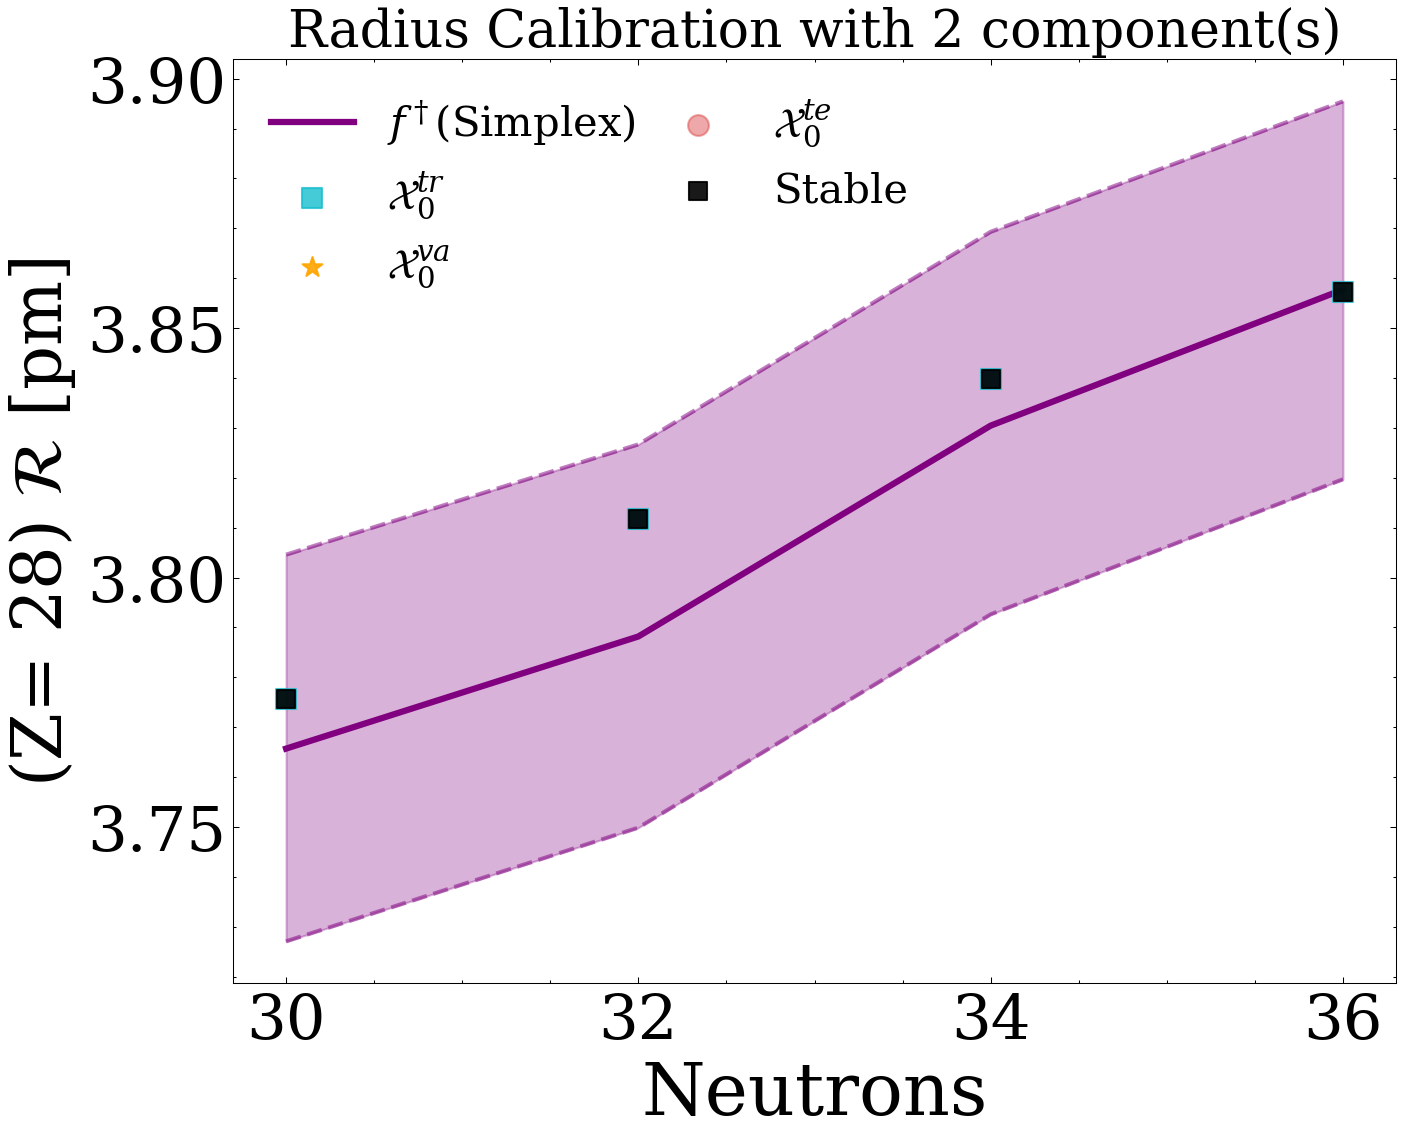

In [ ]:
supermodel_predictions_radius_range_simplex_28 = [lower_radius_simplex_28, median_radius_simplex_28, upper_radius_simplex_28]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel_simplex(supermodel_predictions_radius_range_simplex_28, filtered_models_output_radius_list_28, filtered_models_output_radius_stable_28, 28, 'pm', 'R', 'Simplex', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Ni 28 - Simplex BMM with {components_kept} components - Fy_Dr and Fy_IVP' )
plt.show()

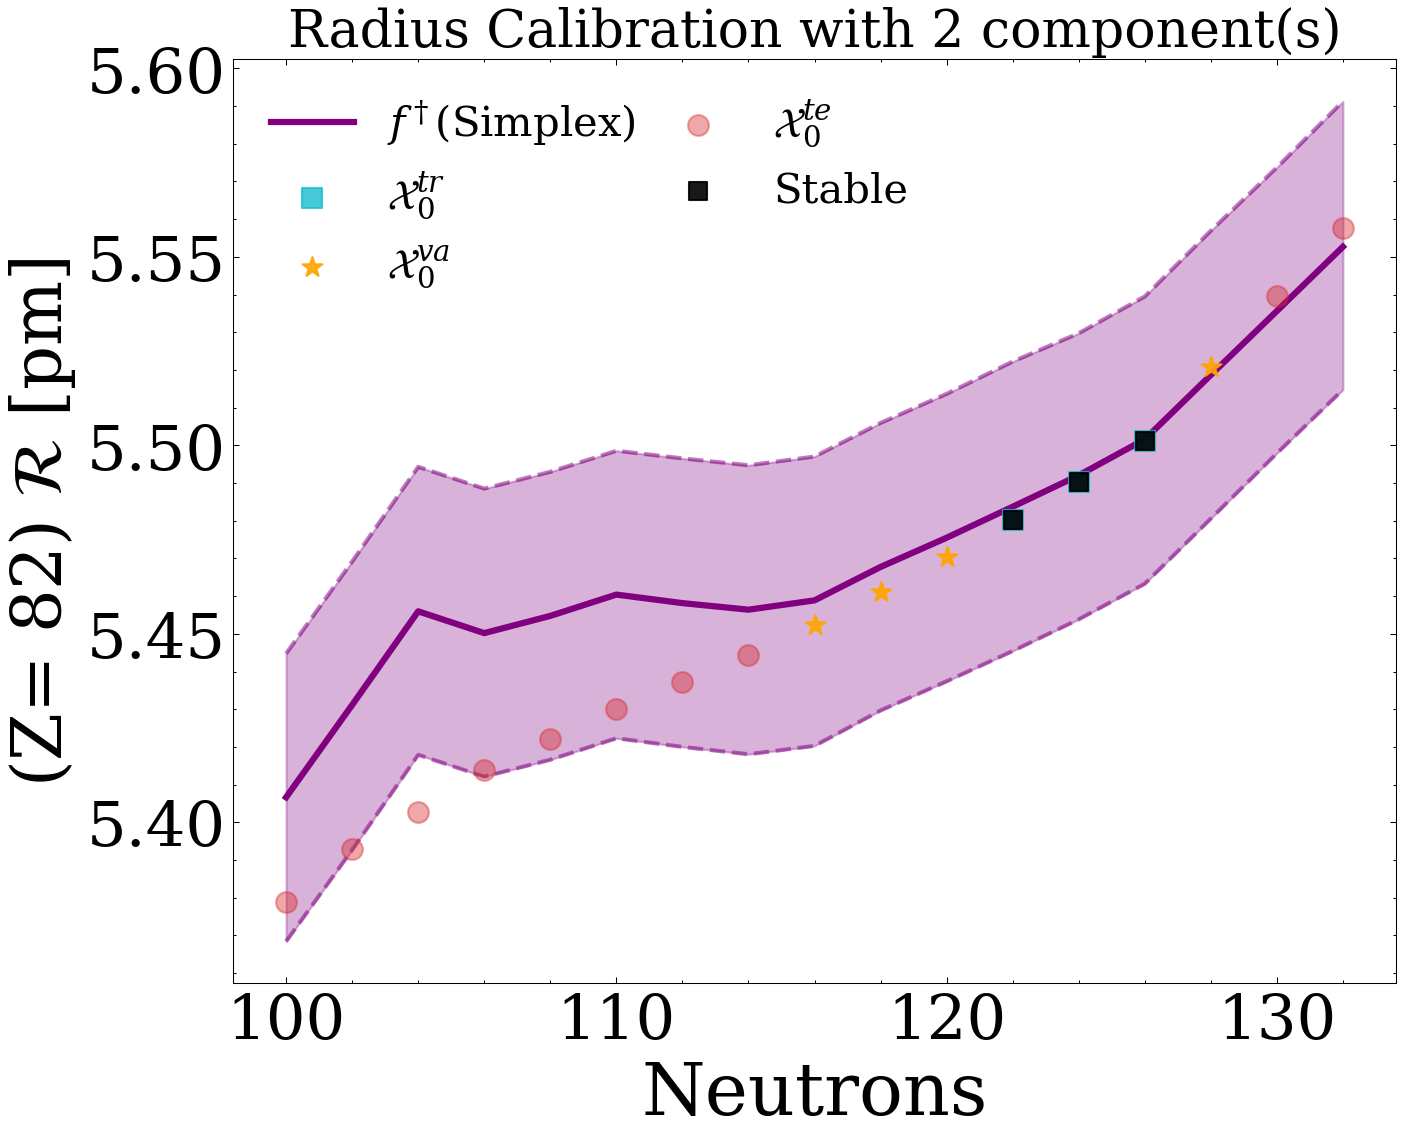

In [ ]:
supermodel_predictions_radius_range_simplex_82 = [lower_radius_simplex_82, median_radius_simplex_82, upper_radius_simplex_82]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel_simplex(supermodel_predictions_radius_range_simplex_82, filtered_models_output_radius_list_82, filtered_models_output_radius_stable_82, 82, 'pm', 'R', 'Simplex', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Ca 20 - Simplex BMM with {components_kept} components - Fy_Dr and Fy_IVP' )
plt.show()

In [79]:
model_predictions_radius_train.shape

(167, 12)

In [81]:
filtered_model_predictions_radius_20.shape

(6, 12)

In [ ]:
# To create the empirical coverage graph, we need to sample bmm predictions from the parameters generated
# from both unconstrained and simplex sampling strategies
rndm_simplex_total, [lower_radius_simplex_total, median_radius_simplex_total, upper_radius_simplex_total] = rndm_m_random_calculator(model_predictions_radius, samples_simplex, Vt_hat)
rndm_simplex_train, [lower_radius_simplex_train, median_radius_simplex_train, upper_radius_simplex_train] = rndm_m_random_calculator(model_predictions_radius_train, samples_simplex, Vt_hat)
rndm_simplex_val, [lower_radius_simplex_val, median_radius_simplex_val, upper_radius_simplex_val] = rndm_m_random_calculator(model_predictions_radius_validation, samples_simplex, Vt_hat)
rndm_simplex_test, [lower_radius_simplex_test, median_radius_simplex_test, upper_radius_simplex_test] = rndm_m_random_calculator(model_predictions_radius_test, samples_simplex, Vt_hat)

rndm_total, [lower_radius_total, median_radius_total, upper_radius_total] = rndm_m_random_calculator(model_predictions_radius, samples, Vt_hat)
rndm_train, [lower_radius_train, median_radius_train, upper_radius_train] = rndm_m_random_calculator(model_predictions_radius_train, samples, Vt_hat)
rndm_val, [lower_radius_val, median_radius_val, upper_radius_val] = rndm_m_random_calculator(model_predictions_radius_validation, samples, Vt_hat)
rndm_test, [lower_radius_test, median_radius_test, upper_radius_test] = rndm_m_random_calculator(model_predictions_radius_test, samples, Vt_hat)

In [ ]:
percentiles = np.arange(0,101,5)

coverage_unconstrained_train = coverage(percentiles, rndm_train, models_output_radius_train, 'truth' )
coverage_unconstrained_validation = coverage(percentiles, rndm_val, models_output_radius_validation, 'truth' )
coverage_unconstrained_test = coverage(percentiles, rndm_test, models_output_radius_test, 'truth' )

coverage_simplex_train = coverage(percentiles, rndm_simplex_train, models_output_radius_train, 'truth' )
coverage_simplex_validation = coverage(percentiles, rndm_simplex_val, models_output_radius_validation, 'truth' )
coverage_simplex_test = coverage(percentiles, rndm_simplex_test, models_output_radius_test, 'truth' )


In [ ]:
models_output_radius

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,Fy_IVP_Bailey,Fy_Dr_Bailey,truth
0,8,8,16,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816,2.774552,2.753890,2.6991
1,10,8,18,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329,2.835790,2.828447,2.7726
2,8,10,18,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445,2.951307,2.993670,2.9714
3,10,10,20,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315,3.000327,3.019625,3.0055
4,12,10,22,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485,3.001396,3.028387,2.9525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,244,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415,5.903815,5.915108,5.8948
341,146,96,242,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126,5.902992,5.911279,5.8285
342,148,96,244,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104,5.915440,5.924613,5.8429
343,150,96,246,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470,5.927410,5.938320,5.8562


<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:21: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:21: SyntaxWarning: invalid escape sequence '\%'
C:\Users\congn\AppData\Local\Temp\ipykernel_3480\3647531261.py:20: SyntaxWarning: invalid escape sequence '\%'
  plt.xlabel('Credible Interval (\%)',fontsize=22)
C:\Users\congn\AppData\Local\Temp\ipykernel_3480\3647531261.py:21: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel('Coverage (\%)',fontsize=22)


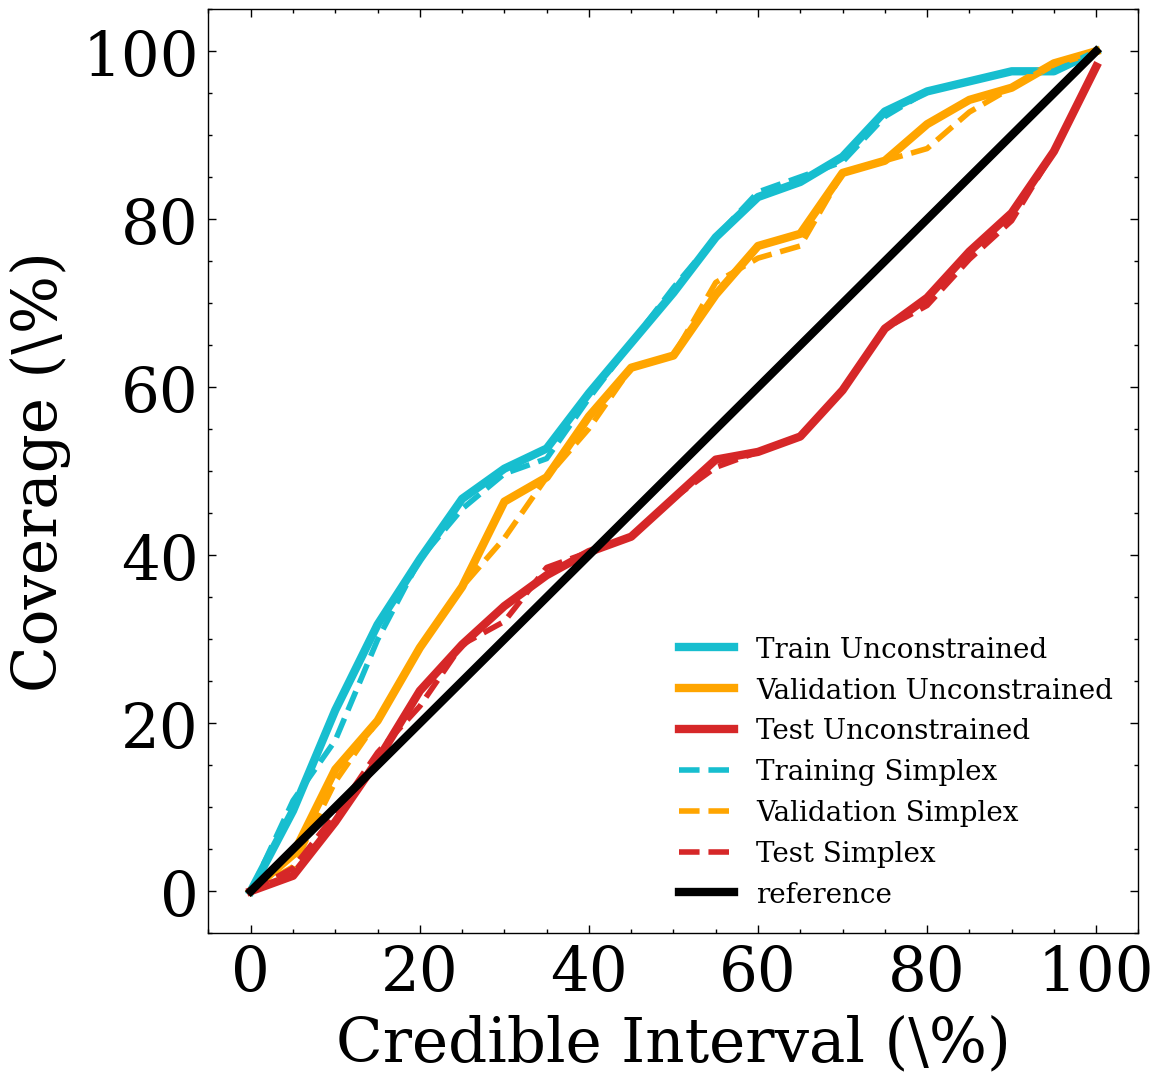

In [ ]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_unconstrained_train, label='Train Unconstrained',color=color_train,linewidth= 3)
plt.plot(percentiles, coverage_unconstrained_validation, label='Validation Unconstrained',color=color_validation,linewidth=3)
plt.plot(percentiles, coverage_unconstrained_test, label='Test Unconstrained',color=color_test,linewidth=3)


plt.plot(percentiles, coverage_simplex_train,linestyle='dashed', label='Training Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_simplex_validation, linestyle='dashed',label='Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_simplex_test,linestyle='dashed', label='Test Simplex',color=color_test,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=3)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,80,100])

# plt.title('Coverage of Observed Data Points by Credible Intervals')
# plt.grid(True)
plt.legend(fontsize=10)

# plt.savefig('Plots/Radii Data with Bailey/Coverage graph/Coverage graph of global radii - FyDr and FyIVP.png')
plt.show()

In [ ]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights_simplex = []
for beta in samples_simplex:
    model_weights_simplex.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex= np.array(model_weights_simplex)

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
C:\Users\congn\AppData\Local\Temp\ipykernel_3480\1879668633.py:21: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega_k$',fontsize=35)


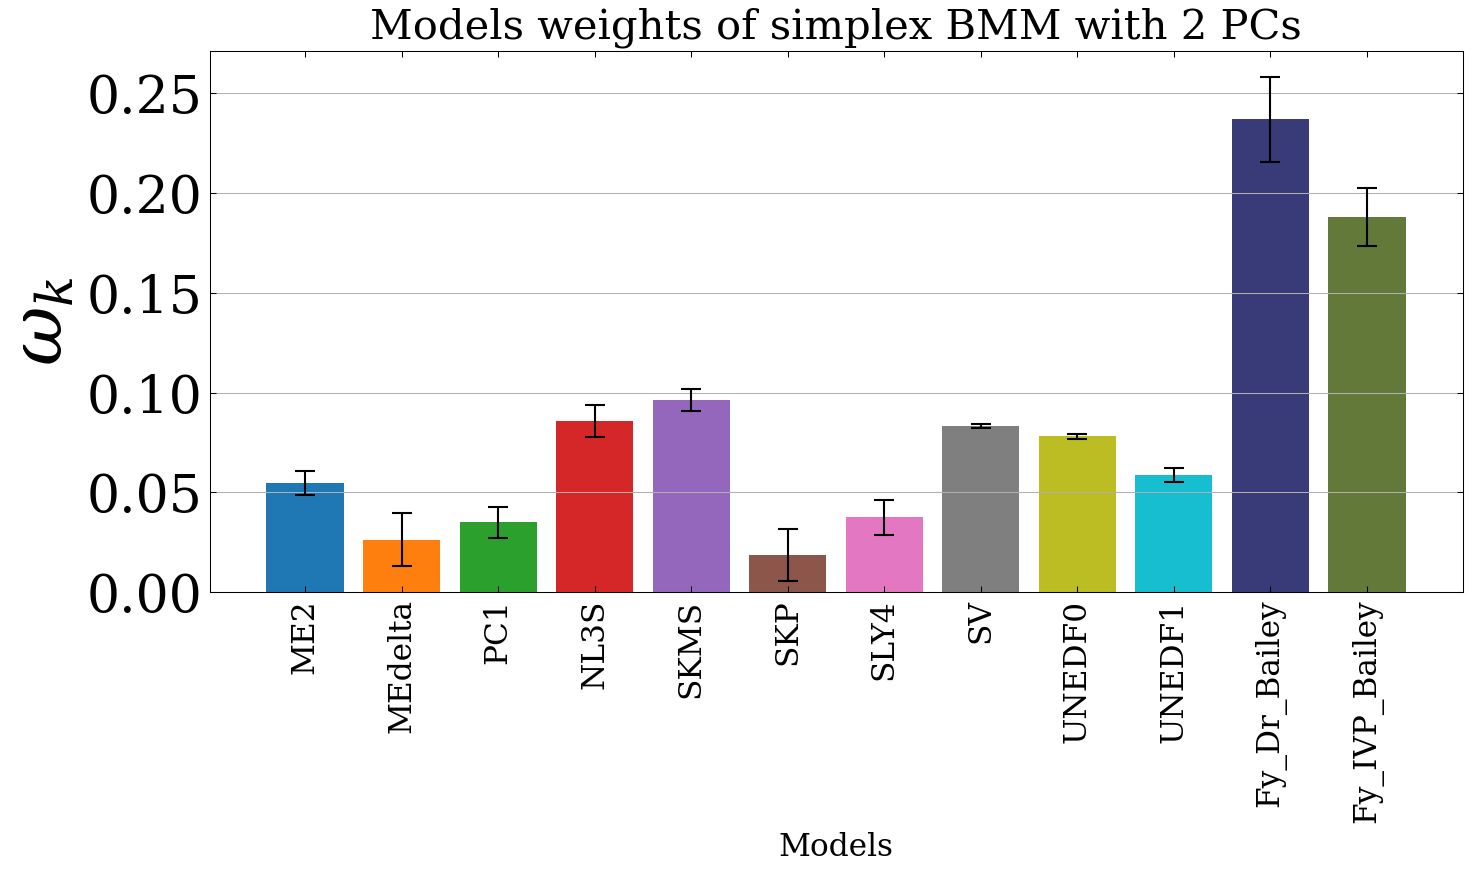

In [ ]:
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
# labels=list(models_output.keys())
plt.figure(figsize=(10, 6),dpi=150)
# y_max=0.6


i=0
for model in models_selected:
        
        # ax.plot(filtered_models_output["N"], filtered_models_output[key_list[model_index]], 
        #         label = n_Labels[class_index], color=colors[class_index],alpha = alpha_models,linewidth=5)
        # plt.bar(model , np.mean(samples_naive_space_sigma.T[i]), color=colors[i])
        plt.bar(model , np.mean(model_weights_simplex.T[i]), yerr=np.std(model_weights_simplex.T[i]), color=colors[i],capsize=5)
        i=i+1

plt.minorticks_off()


plt.xlabel('Models',fontsize=15)
plt.ylabel('$\omega_k$',fontsize=35)
# plt.ylim(-0.2,0.5)
# plt.yticks([0, 0.2, 0.4])
plt.xticks(fontsize=15,rotation='vertical')
plt.yticks(fontsize=25)
plt.grid(axis='y')
plt.title(f'Models weights of simplex BMM with {components_kept} PCs', fontsize= 20)
plt.tight_layout()
# plt.savefig(f'Plots/Radii Data with Bailey/Models weights/Simplex BMM models weights with {components_kept} PCs')
plt.show()

array([0.01808065, 0.01808065, 0.02045425, ..., 0.02913063, 0.02913063,
       0.03071561])